In [ ]:
# Importing all required libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot
from prophet.plot import plot_cross_validation_metric
from prophet.diagnostics import cross_validation, performance_metrics
from datetime import date
from scipy import stats # new
from statsmodels.tsa.stattools import adfuller # new
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX
from scipy.stats import shapiro
import warnings
warnings.filterwarnings("ignore")

np.random.seed(100)

c:\Users\Walla\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
# getting today date and format it to download data for today and today-5 years
##############################################
####today = date.today()
#today_str = today.strftime("%Y-%m-%d")
#five_years_ago = today.replace(year=today.year - 5)
#five_years_ago_str = five_years_ago.strftime("%Y-%m-%d")
#YearsBack = "5y"
#Getting the data and saving the files as CSV
# Uncomment this line if we are going to use a fixed dates
data_amzn = yf.download("AMZN", start="2021-03-19", end="2026-03-19")
#data_amzn = yf.download("AMZN",  period=YearsBack)
data_amzn_file = "AMZN_historical.csv"
data_amzn.to_csv(data_amzn_file)
# Uncomment this line if we are going to use a specific date for reference
data_msft = yf.download("MSFT", start="2021-03-19", end="2026-03-19")
#data_msft = yf.download("MSFT", period=YearsBack)
data_msft_file = "MSFT_historical.csv"
data_msft.to_csv(data_msft_file)

#Import files, rename column date and deleting 2 unused rows
df_msft = pd.read_csv(data_msft_file, index_col=0)
####df_msft = df_msft[["Close", "Volume"]]
df_msft = df_msft.reset_index()
#Applying backward fill
df_msft = df_msft.bfill()
df_msft = df_msft.dropna(how="any")


df_amzn = pd.read_csv(data_amzn_file, index_col=0)
####df_amzn = df_amzn[["Close", "Volume"]]
df_amzn = df_amzn.reset_index()
#Applying backward fill
df_amzn = df_amzn.bfill()
df_amzn = df_amzn.dropna(how="any")

# Remove the rows at 0-indexed positions 1 and 2
df_amzn = df_amzn.drop([0, 1]).reset_index(drop=True)
df_msft = df_msft.drop([0, 1]).reset_index(drop=True)

# Rename the first column to 'date'
df_amzn = df_amzn.rename(columns={df_amzn.columns[0]: 'Date'})
df_msft = df_msft.rename(columns={df_msft.columns[0]: 'Date'})


# Validating data
for col in ["Close", "Volume"]:
    df_amzn[col] = pd.to_numeric(df_amzn[col], errors="coerce")
    df_msft[col] = pd.to_numeric(df_msft[col], errors="coerce")

df_amzn['Date'] = pd.to_datetime(df_amzn['Date'])
df_amzn = df_amzn.sort_values('Date')
#df_amzn = df_amzn.set_index('Date')

df_msft['Date'] = pd.to_datetime(df_msft['Date'])
df_msft = df_msft.sort_values('Date')
#df_msft = df_amzn.set_index('Date')

print()
print(df_amzn.head())
print(df_msft.head())

#Saving the modified datasets
df_amzn.to_csv(data_amzn_file)
df_msft.to_csv(data_msft_file)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


        Date       Close                High                 Low  \
0 2021-03-19  153.748001    153.864501953125   150.8314971923828   
1 2021-03-22  155.543503  156.32899475097656  153.00250244140625   
2 2021-03-23  156.875000  159.10000610351562  156.04249572753906   
3 2021-03-24  154.353500   158.0155029296875  154.25750732421875   
4 2021-03-25  152.313004  155.48899841308594  151.85699462890625   

                 Open    Volume  
0   151.4615020751953  92508000  
1   153.3925018310547  58044000  
2  156.35000610351562  76346000  
3    157.552001953125  59180000  
4  153.64950561523438  71270000  
        Date       Close                High                 Low  \
0 2021-03-19  221.034576  223.06883823635602  220.07501674352017   
1 2021-03-22  226.446442  227.31962962902716   220.8330129672316   
2 2021-03-23  227.972183  231.30185638179913  227.48281307743645   
3 2021-03-24  225.937866   228.3751406817411    225.803528478558   
4 2021-03-25  222.944077  227.35805660601366  

In [3]:
# Convert price/volume columns to numeric (safe even if already numeric)
###############################################################
#for col in ["Close", "Open", "High", "Low", "Volume"]:
#    df_amzn[col] = pd.to_numeric(df_amzn[col], errors="coerce")
#    df_msft[col] = pd.to_numeric(df_msft[col], errors="coerce")
df_amzn = df_amzn.sort_values("Date").reset_index(drop=True)
df_msft = df_msft.sort_values("Date").reset_index(drop=True)

# Calculate daily percentage returns for both stocks
df_amzn["Daily_Return"] = df_amzn["Close"].pct_change().dropna() * 100
df_msft["Daily_Return"] = df_msft["Close"].pct_change().dropna() * 100

# Calculate rolling 30-day and 90-day moving averages
df_amzn["MA30"] = df_amzn["Close"].rolling(30).mean()
df_amzn["MA90"] = df_amzn["Close"].rolling(90).mean()
df_msft["MA30"] = df_msft["Close"].rolling(30).mean()
df_msft["MA90"] = df_msft["Close"].rolling(90).mean()

# Calculate 30-day rolling volatility (std of daily returns)
df_amzn["Roll_Vol30"] = df_amzn["Daily_Return"].rolling(30).std()
df_msft["Roll_Vol30"] = df_msft["Daily_Return"].rolling(30).std()

# Calculate drawdown from all-time high
df_amzn["Drawdown"] = (df_amzn["Close"] - df_amzn["Close"].cummax()) / df_amzn["Close"].cummax() * 100
df_msft["Drawdown"] = (df_msft["Close"] - df_msft["Close"].cummax()) / df_msft["Close"].cummax() * 100

print("Data preparation complete.")
print(f"AMZN: {len(df_amzn)} trading days | {df_amzn['Date'].min().date()} to {df_amzn['Date'].max().date()}")
print(f"MSFT: {len(df_msft)} trading days | {df_msft['Date'].min().date()} to {df_msft['Date'].max().date()}")

Data preparation complete.
AMZN: 1255 trading days | 2021-03-19 to 2026-03-18
MSFT: 1255 trading days | 2021-03-19 to 2026-03-18


In [4]:
# Descriptive stats for closing price
print("AMAZON (AMZN) — Descriptive Statistics")
print(df_amzn[["Close",  "Volume"]].describe().round(2))

print()
print("MICROSOFT (MSFT) — Descriptive Statistics")
print(df_msft[["Close",  "Volume"]].describe().round(2))

print()
print("Close Price Shape (Skewness and Kurtosis)")
for name, df in [("AMZN", df_amzn), ("MSFT", df_msft)]:
    print(f"{name}: Mean=${df['Close'].mean():.2f} | Median=${df['Close'].median():.2f} "
          f"| Std=${df['Close'].std():.2f} | Skew={df['Close'].skew():.3f} | Kurtosis={df['Close'].kurtosis():.3f}")

print()
print("Daily Returns Summary")
print(f"{'Metric':<35} {'AMZN':>10} {'MSFT':>10}")
print("-" * 57)
metrics = [
    ("Mean Daily Return (%)",       df_amzn["Daily_Return"].mean(),      df_msft["Daily_Return"].mean()),
    ("Std Dev / Volatility (%)",    df_amzn["Daily_Return"].std(),       df_msft["Daily_Return"].std()),
    ("Max Single-Day Gain (%)",     df_amzn["Daily_Return"].max(),       df_msft["Daily_Return"].max()),
    ("Max Single-Day Loss (%)",     df_amzn["Daily_Return"].min(),       df_msft["Daily_Return"].min()),
    ("Skewness",                    df_amzn["Daily_Return"].skew(),      df_msft["Daily_Return"].skew()),
    ("Kurtosis (Excess)",           df_amzn["Daily_Return"].kurtosis(), df_msft["Daily_Return"].kurtosis()),
]
for label, va, vm in metrics:
    print(f"{label:<35} {va:>10.4f} {vm:>10.4f}")

AMAZON (AMZN) — Descriptive Statistics
         Close        Volume
count  1255.00  1.255000e+03
mean    166.02  5.670054e+07
std      42.12  2.705043e+07
min      81.82  1.142050e+07
25%     132.03  3.947575e+07
50%     168.97  5.059430e+07
75%     196.11  6.631880e+07
max     254.00  2.726620e+08

MICROSOFT (MSFT) — Descriptive Statistics
         Close        Volume
count  1255.00  1.255000e+03
mean    350.39  2.578093e+07
std      87.27  1.065242e+07
min     208.18  5.855900e+06
25%     272.91  1.894115e+07
50%     329.46  2.327770e+07
75%     415.99  2.961395e+07
max     539.83  1.288553e+08

Close Price Shape (Skewness and Kurtosis)
AMZN: Mean=$166.02 | Median=$168.97 | Std=$42.12 | Skew=-0.047 | Kurtosis=-0.914
MSFT: Mean=$350.39 | Median=$329.46 | Std=$87.27 | Skew=0.288 | Kurtosis=-1.120

Daily Returns Summary
Metric                                    AMZN       MSFT
---------------------------------------------------------
Mean Daily Return (%)                   0.0494     0.

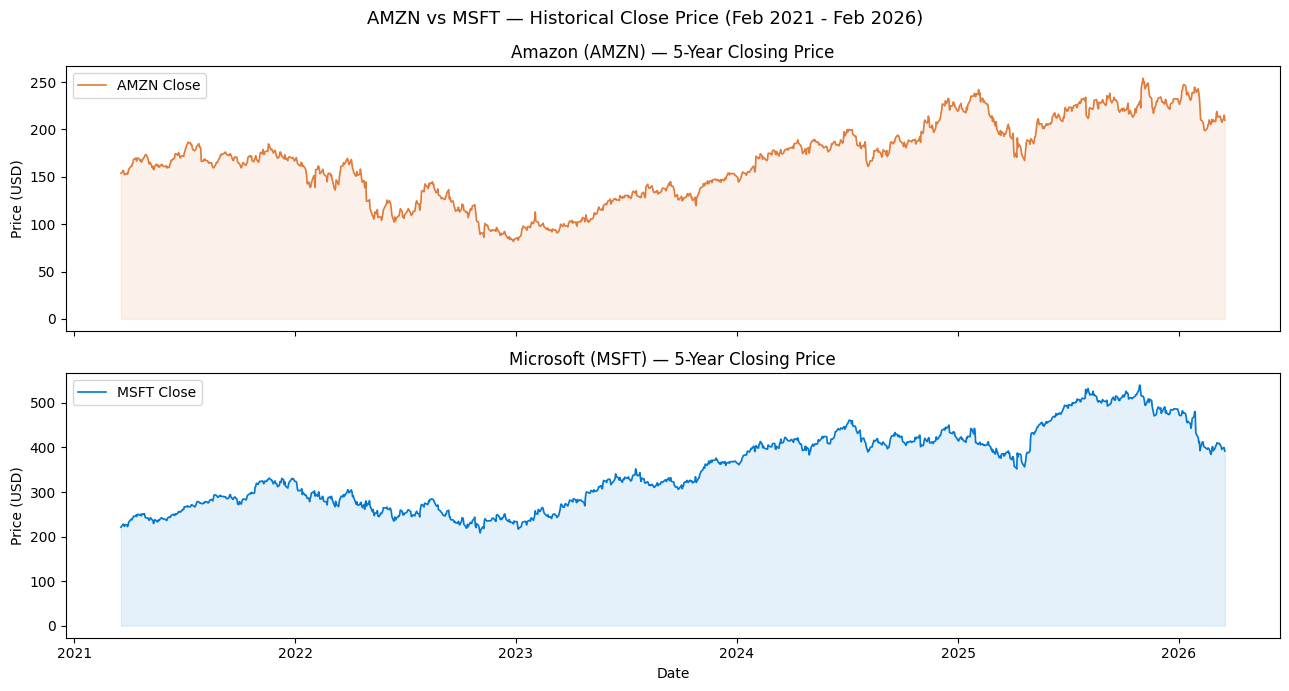

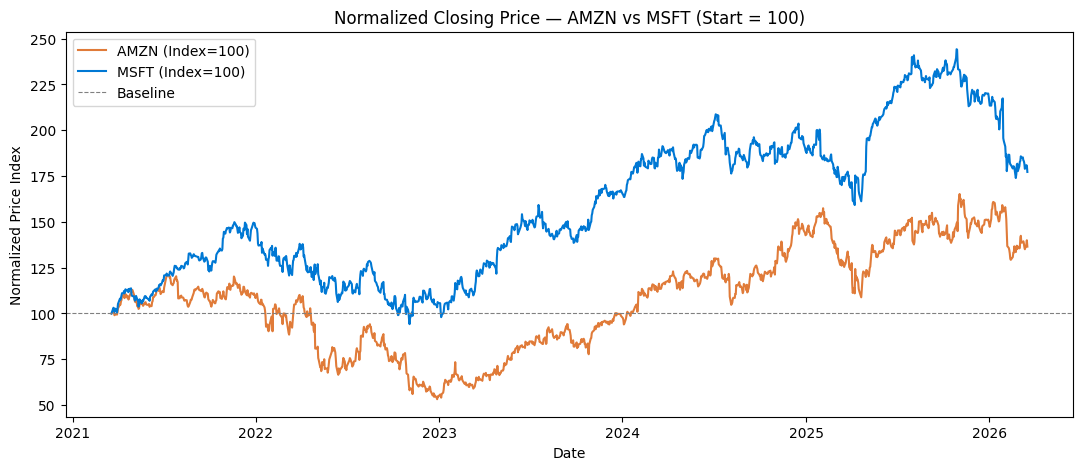

AMZN 5-Year Cumulative Return: 36.50%
MSFT 5-Year Cumulative Return: 77.25%


In [5]:
# Plot 1: Raw closing price for both stocks (stacked)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

ax1.plot(df_amzn["Date"], df_amzn["Close"], color="#e07b39", linewidth=1.2, label="AMZN Close")
ax1.fill_between(df_amzn["Date"], df_amzn["Close"], alpha=0.1, color="#e07b39")
ax1.set_title("Amazon (AMZN) — 5-Year Closing Price")
ax1.set_ylabel("Price (USD)")
ax1.legend()

ax2.plot(df_msft["Date"], df_msft["Close"], color="#0078D4", linewidth=1.2, label="MSFT Close")
ax2.fill_between(df_msft["Date"], df_msft["Close"], alpha=0.1, color="#0078D4")
ax2.set_title("Microsoft (MSFT) — 5-Year Closing Price")
ax2.set_ylabel("Price (USD)")
ax2.set_xlabel("Date")
ax2.legend()

plt.suptitle("AMZN vs MSFT — Historical Close Price (Feb 2021 - Feb 2026)", fontsize=13)
plt.tight_layout()
plt.show()

# Plot 2: Normalized close price (both indexed to 100 at start)
# Normalizing removes price scale difference and shows relative performance
amzn_norm = (df_amzn["Close"] / df_amzn["Close"].iloc[0]) * 100
msft_norm = (df_msft["Close"] / df_msft["Close"].iloc[0]) * 100

plt.figure(figsize=(13, 5))
plt.plot(df_amzn["Date"], amzn_norm, color="#e07b39", linewidth=1.5, label="AMZN (Index=100)")
plt.plot(df_msft["Date"], msft_norm, color="#0078D4", linewidth=1.5, label="MSFT (Index=100)")
plt.axhline(100, color="gray", linestyle="--", linewidth=0.8, label="Baseline")
plt.title("Normalized Closing Price — AMZN vs MSFT (Start = 100)")
plt.ylabel("Normalized Price Index")
plt.xlabel("Date")
plt.legend()
plt.show()

# Print 5-year cumulative return
for name, df in [("AMZN", df_amzn), ("MSFT", df_msft)]:
    total_return = ((df["Close"].iloc[-1] / df["Close"].iloc[0]) - 1) * 100
    print(f"{name} 5-Year Cumulative Return: {total_return:.2f}%")

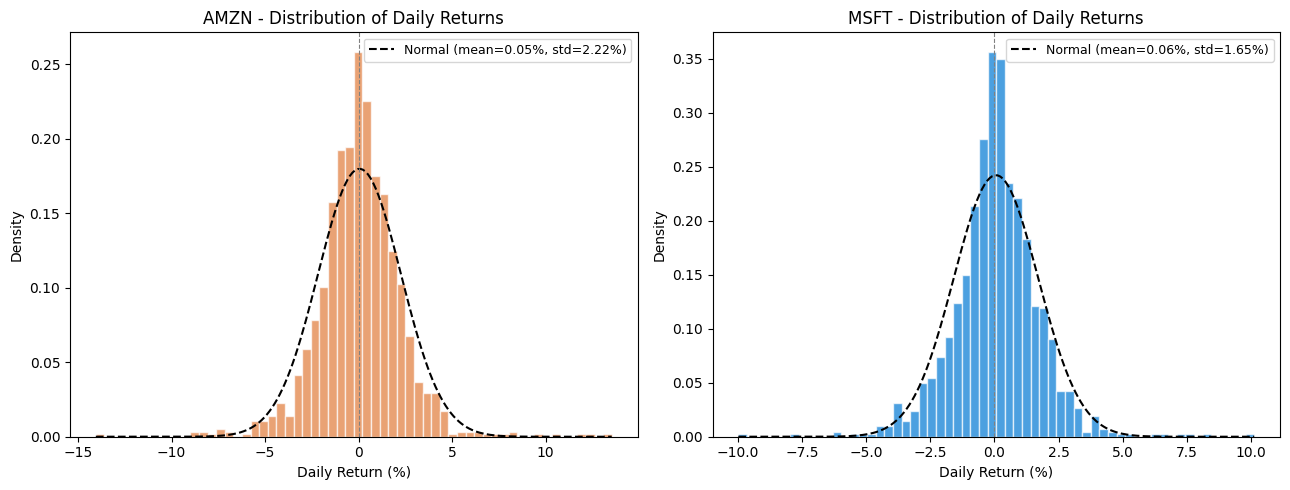

In [6]:
# Plot-3: Distribution of daily returns with normal curve overlay
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for ax, name, df, color in [(ax1, "AMZN", df_amzn, "#e07b39"), (ax2, "MSFT", df_msft, "#0078D4")]:
    returns = df["Daily_Return"].dropna()
    ax.hist(returns, bins=60, color=color, alpha=0.7, edgecolor="white", density=True)
    # Overlay a normal distribution curve for comparison
    mu, sigma = returns.mean(), returns.std()
    x = np.linspace(returns.min(), returns.max(), 200)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), "k--", linewidth=1.5,
            label=f"Normal (mean={mu:.2f}%, std={sigma:.2f}%)")
    ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.set_title(f"{name} - Distribution of Daily Returns")
    ax.set_xlabel("Daily Return (%)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

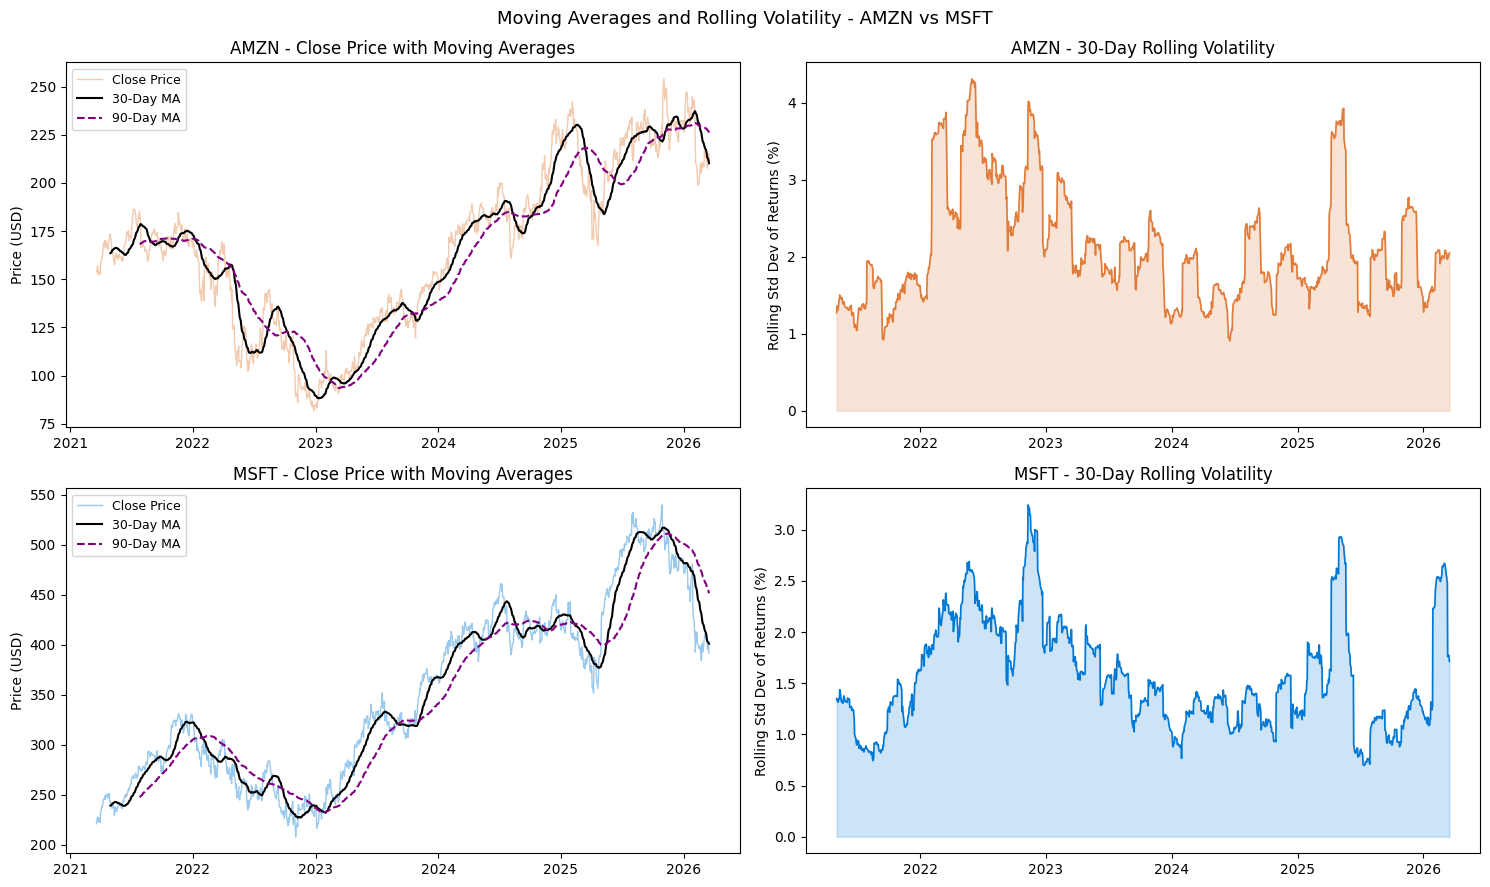

In [7]:
# Plot-4: Moving Averages and Rolling Volatility — AMZN vs MSFT

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

for row, (name, df, color) in enumerate([("AMZN", df_amzn, "#e07b39"), ("MSFT", df_msft, "#0078D4")]):

    # Left column: Close price with 30-day and 90-day moving averages
    axes[row][0].plot(df["Date"], df["Close"], color=color, alpha=0.4, linewidth=1, label="Close Price")
    axes[row][0].plot(df["Date"], df["MA30"], color="black", linewidth=1.5, label="30-Day MA")
    axes[row][0].plot(df["Date"], df["MA90"], color="purple",linewidth=1.5, linestyle="--", label="90-Day MA")
    axes[row][0].set_title(f"{name} - Close Price with Moving Averages")
    axes[row][0].set_ylabel("Price (USD)")
    axes[row][0].legend(fontsize=9)

    # Right column: 30-day rolling volatility (std dev of daily returns)
    axes[row][1].plot(df["Date"], df["Roll_Vol30"], color=color, linewidth=1.2)
    axes[row][1].fill_between(df["Date"], df["Roll_Vol30"], alpha=0.2, color=color)
    axes[row][1].set_title(f"{name} - 30-Day Rolling Volatility")
    axes[row][1].set_ylabel("Rolling Std Dev of Returns (%)")

plt.suptitle("Moving Averages and Rolling Volatility - AMZN vs MSFT", fontsize=13)
plt.tight_layout()
plt.show()

In [8]:
#Correlation among AMZN and MSFT
usedColumn = "Close"
corr_index = df_amzn[usedColumn].corr(df_msft[usedColumn])
print(f"Correlation between AMZN and MSFT closing prices: {corr_index:.4f}")

Correlation between AMZN and MSFT closing prices: 0.8345


Pearson Correlation — Closing Prices:  r = 0.8349  (p = 0.00e+00)
Pearson Correlation — Daily Returns:   r = 0.6349  (p = 1.88e-142)


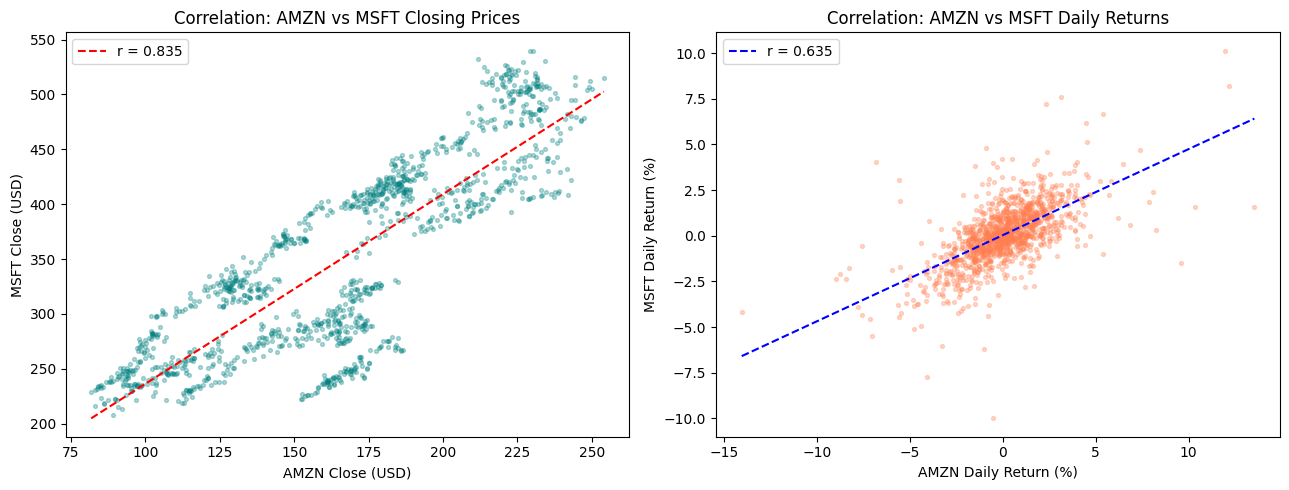

In [9]:
# Plot-5: Correlation: AMZN vs MSFT Closing Prices and Daily Returns

# Merge both datasets on Date for side-by-side comparison
merged = pd.merge(
    df_amzn[["Date", "Close", "Daily_Return"]].rename(columns={"Close": "AMZN_Close", "Daily_Return": "AMZN_Return"}),
    df_msft[["Date", "Close", "Daily_Return"]].rename(columns={"Close": "MSFT_Close", "Daily_Return": "MSFT_Return"}),
    on="Date"
)
merged_clean = merged.dropna()

r_price, p_price = stats.pearsonr(merged_clean["AMZN_Close"],  merged_clean["MSFT_Close"])
r_ret,   p_ret   = stats.pearsonr(merged_clean["AMZN_Return"], merged_clean["MSFT_Return"])

print(f"Pearson Correlation — Closing Prices:  r = {r_price:.4f}  (p = {p_price:.2e})")
print(f"Pearson Correlation — Daily Returns:   r = {r_ret:.4f}  (p = {p_ret:.2e})")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: Closing prices
ax1.scatter(merged_clean["AMZN_Close"], merged_clean["MSFT_Close"], alpha=0.3, s=8, color="teal")
m, b = np.polyfit(merged_clean["AMZN_Close"], merged_clean["MSFT_Close"], 1)
x_fit = np.linspace(merged_clean["AMZN_Close"].min(), merged_clean["AMZN_Close"].max(), 200)
ax1.plot(x_fit, m * x_fit + b, "r--", linewidth=1.5, label=f"r = {r_price:.3f}")
ax1.set_title("Correlation: AMZN vs MSFT Closing Prices")
ax1.set_xlabel("AMZN Close (USD)")
ax1.set_ylabel("MSFT Close (USD)")
ax1.legend()

# Scatter: Daily returns
ax2.scatter(merged_clean["AMZN_Return"], merged_clean["MSFT_Return"], alpha=0.3, s=8, color="coral")
m2, b2 = np.polyfit(merged_clean["AMZN_Return"], merged_clean["MSFT_Return"], 1)
x_fit2 = np.linspace(merged_clean["AMZN_Return"].min(), merged_clean["AMZN_Return"].max(), 200)
ax2.plot(x_fit2, m2 * x_fit2 + b2, "b--", linewidth=1.5, label=f"r = {r_ret:.3f}")
ax2.set_title("Correlation: AMZN vs MSFT Daily Returns")
ax2.set_xlabel("AMZN Daily Return (%)")
ax2.set_ylabel("MSFT Daily Return (%)")
ax2.legend()

plt.tight_layout()
plt.show()

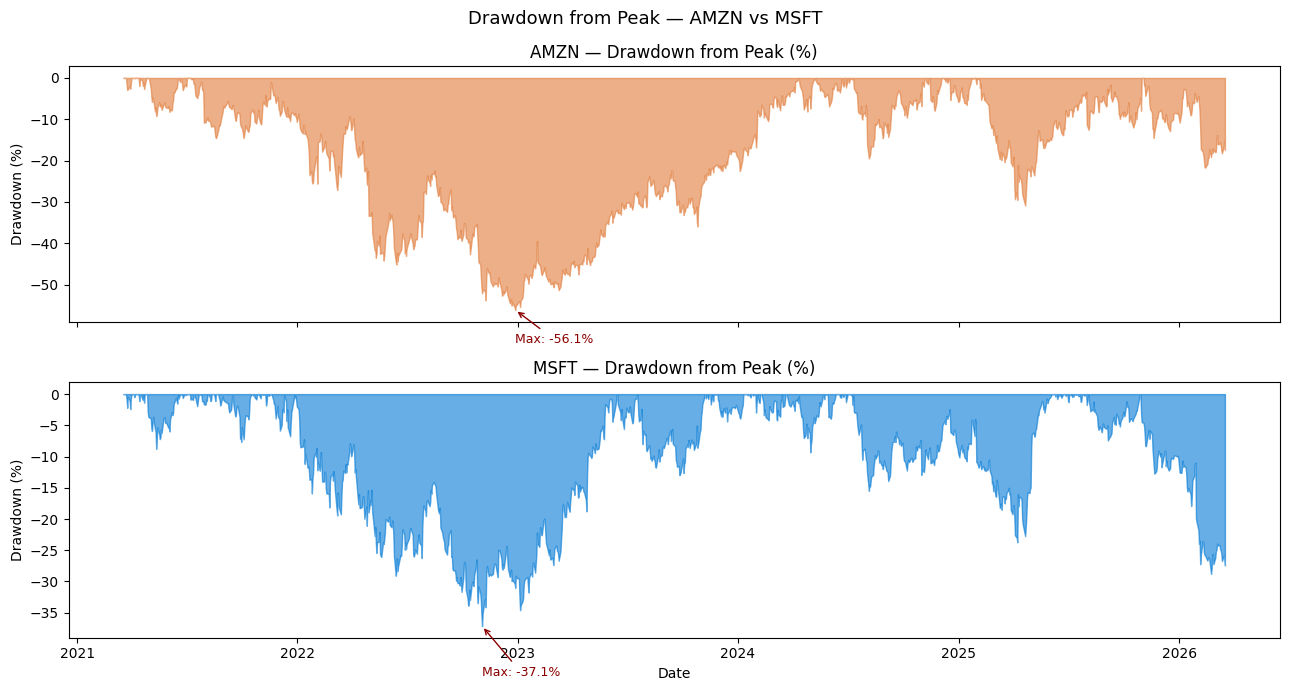

AMZN Maximum Drawdown: -56.15% on 2022-12-28
MSFT Maximum Drawdown: -37.15% on 2022-11-03

Annual Returns (%) by Year:
 Year  AMZN_Return_%  MSFT_Return_%
 2022         -50.71         -27.69
 2023          77.04          58.35
 2024          46.33          14.50
 2025           4.81          16.39



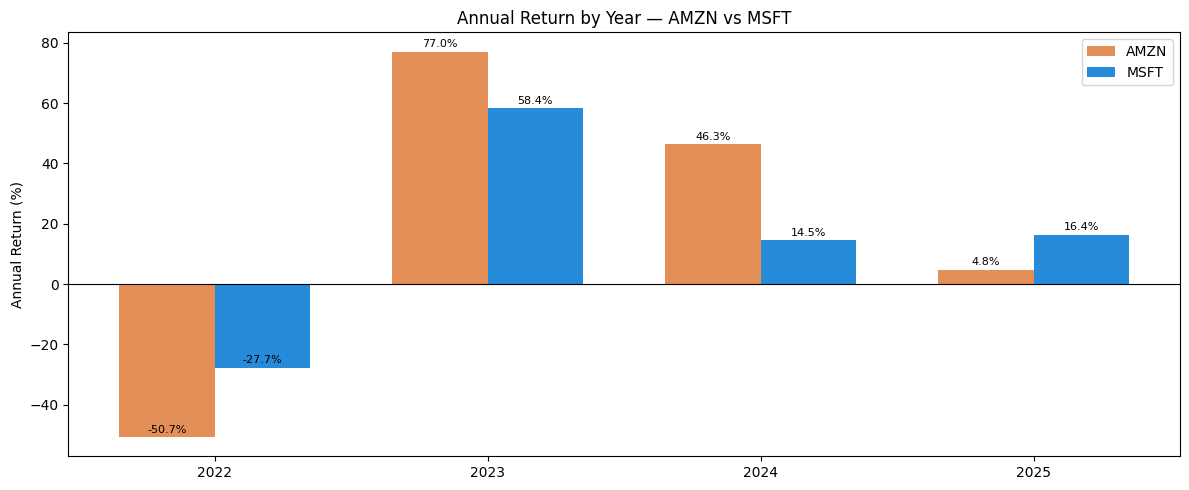

In [10]:
# Plot-6: Drawdown from all-time high
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

for ax, name, df, color in [(ax1, "AMZN", df_amzn, "#e07b39"), (ax2, "MSFT", df_msft, "#0078D4")]:
    ax.fill_between(df["Date"], df["Drawdown"], 0, color=color, alpha=0.6)
    ax.set_title(f"{name} — Drawdown from Peak (%)")
    ax.set_ylabel("Drawdown (%)")
    # Annotate the maximum drawdown point
    max_dd_idx = df["Drawdown"].idxmin()
    max_dd_val = df.loc[max_dd_idx, "Drawdown"]
    max_dd_date = df.loc[max_dd_idx, "Date"]
    ax.annotate(f"Max: {max_dd_val:.1f}%",
                xy=(max_dd_date, max_dd_val),
                xytext=(max_dd_date, max_dd_val - 8),
                fontsize=9, color="darkred",
                arrowprops=dict(arrowstyle="->", color="darkred"))

ax2.set_xlabel("Date")
plt.suptitle("Drawdown from Peak — AMZN vs MSFT", fontsize=13)
plt.tight_layout()
plt.show()

for name, df in [("AMZN", df_amzn), ("MSFT", df_msft)]:
    max_dd = df["Drawdown"].min()
    max_dd_date = df.loc[df["Drawdown"].idxmin(), "Date"].strftime("%Y-%m-%d")
    print(f"{name} Maximum Drawdown: {max_dd:.2f}% on {max_dd_date}")

print()

# Plot-7: Annual return by year for both stocks
def get_annual_returns(df, name):
    # Calculates the percentage return for each calendar year
    df["Year"] = df["Date"].dt.year
    results = []
    for yr, grp in df.groupby("Year"):
        grp = grp.sort_values("Date")
        ret = ((grp["Close"].iloc[-1] / grp["Close"].iloc[0]) - 1) * 100
        results.append({"Year": yr, f"{name}_Return_%": round(ret, 2)})
    return pd.DataFrame(results)

amzn_annual = get_annual_returns(df_amzn, "AMZN")
msft_annual = get_annual_returns(df_msft, "MSFT")
annual = pd.merge(amzn_annual, msft_annual, on="Year")
annual = annual[annual["Year"].isin([2022, 2023, 2024, 2025])] # Plotting only complete years

print("Annual Returns (%) by Year:")
print(annual.to_string(index=False))
print()

x = np.arange(len(annual))
width = 0.35

plt.figure(figsize=(12, 5))
bars_amzn = plt.bar(x - width/2, annual["AMZN_Return_%"], width, label="AMZN", color="#e07b39", alpha=0.85)
bars_msft = plt.bar(x + width/2, annual["MSFT_Return_%"], width, label="MSFT", color="#0078D4", alpha=0.85)
plt.axhline(0, color="black", linewidth=0.8)
plt.xticks(x, annual["Year"])
plt.title("Annual Return by Year — AMZN vs MSFT")
plt.ylabel("Annual Return (%)")
plt.legend()

# Label each bar with its value
for bar in bars_amzn:
    h = bar.get_height()
    plt.annotate(f"{h:.1f}%", xy=(bar.get_x() + bar.get_width() / 2, h),
                 xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8)
for bar in bars_msft:
    h = bar.get_height()
    plt.annotate(f"{h:.1f}%", xy=(bar.get_x() + bar.get_width() / 2, h),
                 xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

Using different models to chose the best fit

In [11]:
# Setting common parameters
FORECAST_DAYS = 30
INTERVAL_WIDTH = 0.95
usedColumn = "Close"
all_metrics = []
AMZN_Name = "AMZN"
MSFT_Name = "MSFT"
z = 1.96  # For confidence intervals
train_msft = df_msft.iloc[:-FORECAST_DAYS]
test_msft  = df_msft.iloc[-FORECAST_DAYS:]
train_amzn = df_amzn.iloc[:-FORECAST_DAYS]
test_amzn  = df_amzn.iloc[-FORECAST_DAYS:]

In [12]:
def calculate_metrics(actual, predicted,Stock,model):
    actual = np.array(actual)
    predicted = np.array(predicted)

    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)

    actual_safe = np.where(actual == 0, np.nan, actual)
    mape = np.nanmean(np.abs((actual - predicted) / actual_safe)) * 100

    #mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    print(f"{Stock} Metrics")

    #mean_actual = actual.mean()
    mean_actual = np.nanmean(actual)

    relative_mae = mae / mean_actual
    relative_rmse = rmse / mean_actual
    relative_mse = mse / (mean_actual**2)
    print("------------------------------------")
    print(f"Evaluation on Test Set {Stock}:")
    print(f"MAE: {mae:.2f}, Relative MAE: {relative_mae:.2%}")
    print(f"MAPE: {mape:.2f}%")
    print(f"RMSE: {rmse:.2f}, Relative RMSE: {relative_rmse:.2%}")
    print(f"MSE: {mse:.2f}, Relative MSE: {relative_mse:.2%}")
    print("------------------------------------")
    return {
        "Stock": Stock,"Model": model,"MAE": mae,"Relative_MAE": relative_mae,
        "MAPE": mape,"RMSE": rmse,"Relative_RMSE": relative_rmse,
        "MSE": mse,"Relative_MSE": relative_mse}
    #return mae, mse, rmse, mape

Exponential smoothing

MSFT Metrics
------------------------------------
Evaluation on Test Set MSFT:
MAE: 12.08, Relative MAE: 3.01%
MAPE: 3.04%
RMSE: 13.73, Relative RMSE: 3.42%
MSE: 188.62, Relative MSE: 0.12%
------------------------------------
AMZN Metrics
------------------------------------
Evaluation on Test Set AMZN:
MAE: 29.49, Relative MAE: 14.03%
MAPE: 14.14%
RMSE: 30.24, Relative RMSE: 14.38%
MSE: 914.22, Relative MSE: 2.07%
------------------------------------


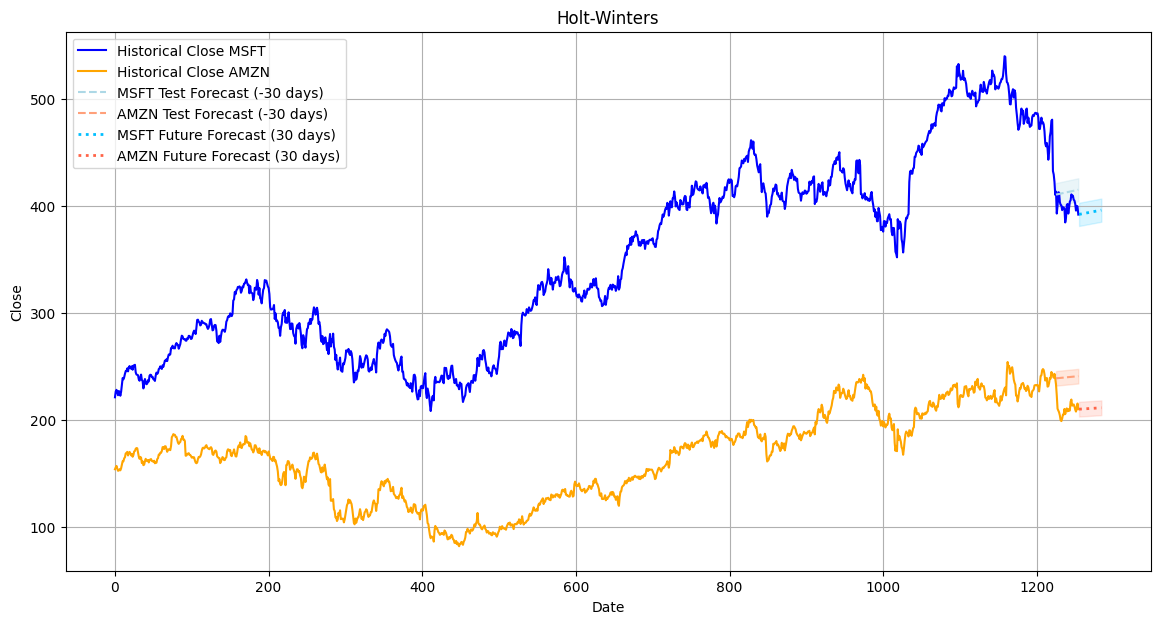

In [13]:
model="Exponential Smoothing"


# 1. Fit Holt-Winters model (additive trend, no seasonality)
model_msft_test = ExponentialSmoothing(train_msft[usedColumn], trend='add', seasonal=None)
fit_msft_test = model_msft_test.fit()
model_amzn_test = ExponentialSmoothing(train_amzn[usedColumn], trend='add', seasonal=None)
fit_amzn_test = model_amzn_test.fit()

# 2. Forecast last 30 days
forecast_msft_test = fit_msft_test.forecast(FORECAST_DAYS)
forecast_amzn_test = fit_amzn_test.forecast(FORECAST_DAYS)

# 3. Align forecast index with test index
forecast_msft_test.index = test_msft.index
forecast_amzn_test.index = test_amzn.index

# 4. Calculating the errors using a def for test period
#mae_msft, mse_msft, rmse_msft, mape_msft = calculate_metrics(test_msft[usedColumn], forecast_msft_test,"MSFT Test")
#mae_amzn, mse_amzn, rmse_amzn, mape_amzn = calculate_metrics(test_amzn[usedColumn], forecast_amzn_test,"AMZN Test")

result_error = calculate_metrics(test_msft[usedColumn], forecast_msft_test,MSFT_Name,model)
all_metrics.append(result_error)
result_error = calculate_metrics(test_amzn[usedColumn], forecast_amzn_test,AMZN_Name,model)
all_metrics.append(result_error)


# 5. Creating confidence intervals for test period
resid_msft_test = train_msft[usedColumn] - fit_msft_test.fittedvalues
resid_amzn_test = train_amzn[usedColumn] - fit_amzn_test.fittedvalues
sigma_msft_test = resid_msft_test.std()
sigma_amzn_test = resid_amzn_test.std()
lower_msft_test = forecast_msft_test - z * sigma_msft_test
upper_msft_test = forecast_msft_test + z * sigma_msft_test
lower_amzn_test = forecast_amzn_test - z * sigma_amzn_test
upper_amzn_test = forecast_amzn_test + z * sigma_amzn_test

# 6. Refit wit full dataset to create a forecast for the next 30days
model_msft_full = ExponentialSmoothing(df_msft[usedColumn],trend='add', seasonal=None)
fit_msft_full = model_msft_full.fit()
model_amzn_full = ExponentialSmoothing(df_amzn[usedColumn],trend='add',seasonal=None)
fit_amzn_full = model_amzn_full.fit()

# 7. Forecast next 30 days
forecast_msft_future = fit_msft_full.forecast(FORECAST_DAYS)
forecast_amzn_future = fit_amzn_full.forecast(FORECAST_DAYS)

# 8. Creating confidence intervals for test period
resid_msft_full = df_msft[usedColumn] - fit_msft_full.fittedvalues
resid_amzn_full = df_amzn[usedColumn] - fit_amzn_full.fittedvalues
sigma_msft_full = resid_msft_full.std()
sigma_amzn_full = resid_amzn_full.std()
lower_msft_future = forecast_msft_future - z * sigma_msft_full
upper_msft_future = forecast_msft_future + z * sigma_msft_full
lower_amzn_future = forecast_amzn_future - z * sigma_amzn_full
upper_amzn_future = forecast_amzn_future + z * sigma_amzn_full


# 6. Visualization
plt.figure(figsize=(14,7))
# plotting historical Data
plt.plot(df_msft.index, df_msft[usedColumn], label=f"Historical {usedColumn} MSFT", color="blue")
plt.plot(df_amzn.index, df_amzn[usedColumn], label=f"Historical {usedColumn} AMZN", color="orange")
# Plotting Test Forecast
plt.plot(forecast_msft_test.index, forecast_msft_test, linestyle='--', label=f'MSFT Test Forecast (-{FORECAST_DAYS} days)', color="lightblue")
plt.plot(forecast_amzn_test.index, forecast_amzn_test, linestyle='--', label=f'AMZN Test Forecast (-{FORECAST_DAYS} days)', color="lightsalmon")
# Ploting Test confidence intervals
plt.fill_between(forecast_msft_test.index, lower_msft_test, upper_msft_test,color="lightblue", alpha=0.25)
plt.fill_between(forecast_amzn_test.index, lower_amzn_test, upper_amzn_test,color="lightsalmon", alpha=0.25)
# Future forecasts
plt.plot(forecast_msft_future.index, forecast_msft_future,linestyle=':', linewidth=2, color="deepskyblue",label=f"MSFT Future Forecast ({FORECAST_DAYS} days)")
plt.plot(forecast_amzn_future.index, forecast_amzn_future,linestyle=':', linewidth=2, color="tomato",label=f"AMZN Future Forecast ({FORECAST_DAYS} days)")
# Future confidence intervals
plt.fill_between(forecast_msft_future.index, lower_msft_future, upper_msft_future,color="deepskyblue", alpha=0.15)
plt.fill_between(forecast_amzn_future.index, lower_amzn_future, upper_amzn_future,color="tomato", alpha=0.15)

plt.title("Holt-Winters")
plt.xlabel("Date")
plt.ylabel(f"{usedColumn}")
plt.legend()
plt.grid(True)
plt.show()

Exponential Smoothing (Holt-Winters) Method, with damped trend, additive seasonality, additive trending, and seasonal periods as one full year

MSFT Metrics
------------------------------------
Evaluation on Test Set MSFT:
MAE: 18.67, Relative MAE: 4.65%
MAPE: 4.68%
RMSE: 20.27, Relative RMSE: 5.05%
MSE: 410.75, Relative MSE: 0.26%
------------------------------------
AMZN Metrics
------------------------------------
Evaluation on Test Set AMZN:
MAE: 31.94, Relative MAE: 15.19%
MAPE: 15.28%
RMSE: 32.59, Relative RMSE: 15.50%
MSE: 1062.28, Relative MSE: 2.40%
------------------------------------


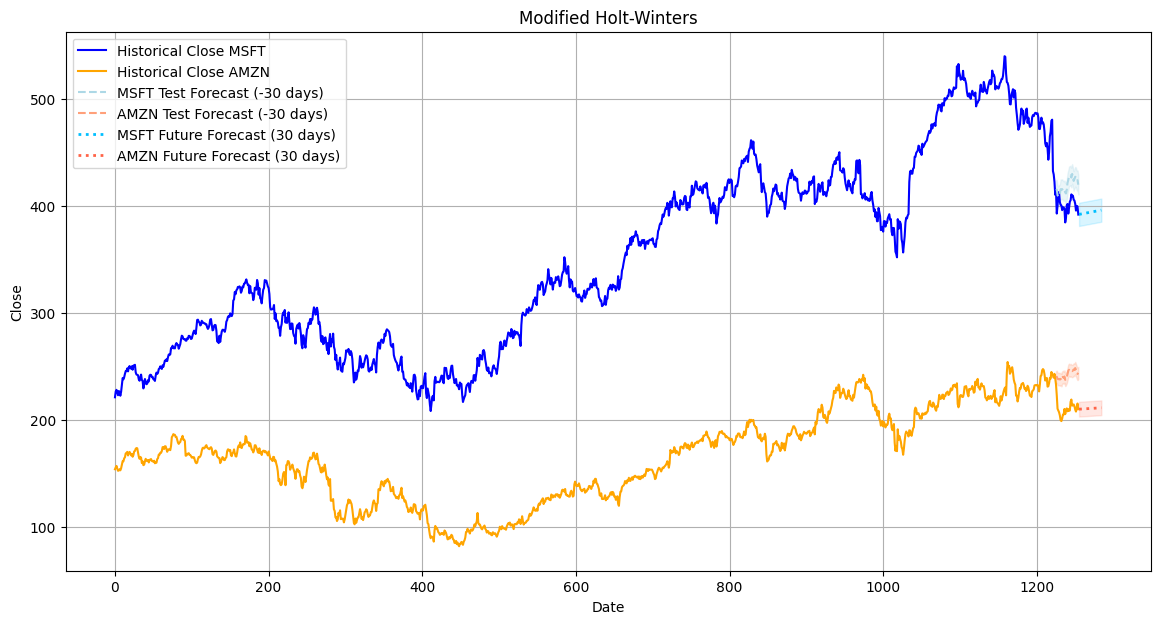

In [14]:
model="Modified Exponential Smoothing"
# 1. Fit Holt-Winters second model (with damped trend, additive seasonality, additive trending, and seasonal periods as one full year)
model_msft_test = ExponentialSmoothing(train_msft[usedColumn], trend='add', seasonal='add',
            seasonal_periods=365, damped_trend=True, initialization_method = "estimated")
fit_msft_test = model_msft_test.fit()
model_amzn_test = ExponentialSmoothing(train_amzn[usedColumn], trend='add', seasonal='add',
            seasonal_periods=365, damped_trend=True, initialization_method = "estimated")
fit_amzn_test = model_amzn_test.fit()

# 2. Forecast last 30 days
forecast_msft_test = fit_msft_test.forecast(FORECAST_DAYS)
forecast_amzn_test = fit_amzn_test.forecast(FORECAST_DAYS)

# 3. Align forecast index with test index
forecast_msft_test.index = test_msft.index
forecast_amzn_test.index = test_amzn.index

# 4. Calculating the errors using a def for test period
result_error = calculate_metrics(test_msft[usedColumn], forecast_msft_test,MSFT_Name,model)
all_metrics.append(result_error)
result_error = calculate_metrics(test_amzn[usedColumn], forecast_amzn_test,AMZN_Name,model)
all_metrics.append(result_error)



# 5. Creating confidence intervals for test period
resid_msft_test = train_msft[usedColumn] - fit_msft_test.fittedvalues
resid_amzn_test = train_amzn[usedColumn] - fit_amzn_test.fittedvalues
sigma_msft_test = resid_msft_test.std()
sigma_amzn_test = resid_amzn_test.std()
lower_msft_test = forecast_msft_test - z * sigma_msft_test
upper_msft_test = forecast_msft_test + z * sigma_msft_test
lower_amzn_test = forecast_amzn_test - z * sigma_amzn_test
upper_amzn_test = forecast_amzn_test + z * sigma_amzn_test

# 6. Refit wit full dataset to create a forecast for the next 30days
model_msft_full = ExponentialSmoothing(df_msft[usedColumn],trend='add', seasonal=None)
fit_msft_full = model_msft_full.fit()
model_amzn_full = ExponentialSmoothing(df_amzn[usedColumn],trend='add',seasonal=None)
fit_amzn_full = model_amzn_full.fit()

# 7. Forecast next 30 days
forecast_msft_future = fit_msft_full.forecast(FORECAST_DAYS)
forecast_amzn_future = fit_amzn_full.forecast(FORECAST_DAYS)

# 8. Creating confidence intervals for test period
resid_msft_full = df_msft[usedColumn] - fit_msft_full.fittedvalues
resid_amzn_full = df_amzn[usedColumn] - fit_amzn_full.fittedvalues
sigma_msft_full = resid_msft_full.std()
sigma_amzn_full = resid_amzn_full.std()
lower_msft_future = forecast_msft_future - z * sigma_msft_full
upper_msft_future = forecast_msft_future + z * sigma_msft_full
lower_amzn_future = forecast_amzn_future - z * sigma_amzn_full
upper_amzn_future = forecast_amzn_future + z * sigma_amzn_full


# 6. Visualization
plt.figure(figsize=(14,7))
# plotting historical Data
plt.plot(df_msft.index, df_msft[usedColumn], label=f"Historical {usedColumn} MSFT", color="blue")
plt.plot(df_amzn.index, df_amzn[usedColumn], label=f"Historical {usedColumn} AMZN", color="orange")
# Plotting Test Forecast
plt.plot(forecast_msft_test.index, forecast_msft_test, linestyle='--', label=f'MSFT Test Forecast (-{FORECAST_DAYS} days)', color="lightblue")
plt.plot(forecast_amzn_test.index, forecast_amzn_test, linestyle='--', label=f'AMZN Test Forecast (-{FORECAST_DAYS} days)', color="lightsalmon")
# Ploting Test confidence intervals
plt.fill_between(forecast_msft_test.index, lower_msft_test, upper_msft_test,color="lightblue", alpha=0.25)
plt.fill_between(forecast_amzn_test.index, lower_amzn_test, upper_amzn_test,color="lightsalmon", alpha=0.25)
# Future forecasts
plt.plot(forecast_msft_future.index, forecast_msft_future,linestyle=':', linewidth=2, color="deepskyblue",label=f"MSFT Future Forecast ({FORECAST_DAYS} days)")
plt.plot(forecast_amzn_future.index, forecast_amzn_future,linestyle=':', linewidth=2, color="tomato",label=f"AMZN Future Forecast ({FORECAST_DAYS} days)")
# Future confidence intervals
plt.fill_between(forecast_msft_future.index, lower_msft_future, upper_msft_future,color="deepskyblue", alpha=0.15)
plt.fill_between(forecast_amzn_future.index, lower_amzn_future, upper_amzn_future,color="tomato", alpha=0.15)

plt.title("Modified Holt-Winters")
plt.xlabel("Date")
plt.ylabel(f"{usedColumn}")
plt.legend()
plt.grid(True)
plt.show()

SARIMA

MSFT Metrics
------------------------------------
Evaluation on Test Set MSFT:
MAE: 15.07, Relative MAE: 3.76%
MAPE: 3.79%
RMSE: 16.51, Relative RMSE: 4.12%
MSE: 272.73, Relative MSE: 0.17%
------------------------------------
AMZN Metrics
------------------------------------
Evaluation on Test Set AMZN:
MAE: 29.14, Relative MAE: 13.86%
MAPE: 13.97%
RMSE: 29.87, Relative RMSE: 14.21%
MSE: 892.35, Relative MSE: 2.02%
------------------------------------


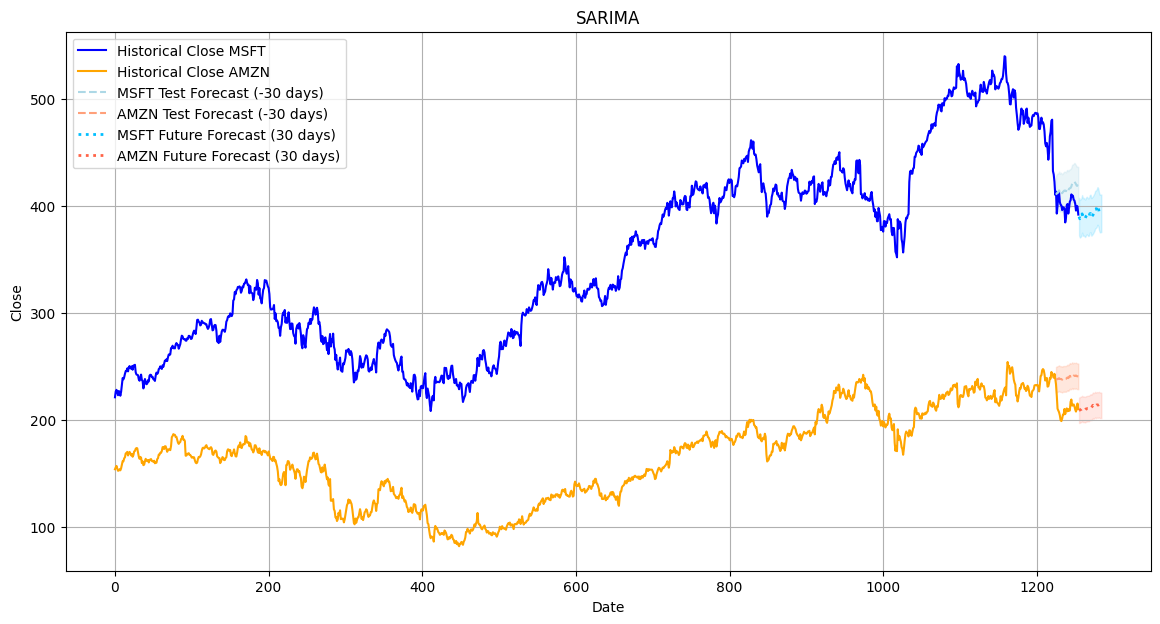

In [15]:
model="SARIMA"
# 1. Fit Holt-Winters second model (with damped trend, additive seasonality, additive trending, and sesonal periods as one full year)
model_msft_test = SARIMAX(train_msft[usedColumn], order=(2,1,2), seasonal_order=(1,1,1,30))
fit_msft_test = model_msft_test.fit(disp=False)
model_amzn_test = SARIMAX(train_amzn[usedColumn], order=(2,1,2), seasonal_order=(1,1,1,30))
fit_amzn_test = model_amzn_test.fit(disp=False)


# 2. Forecast last 30 days
forecast_msft_test = fit_msft_test.forecast(FORECAST_DAYS)
forecast_amzn_test = fit_amzn_test.forecast(FORECAST_DAYS)

# 3. Align forecast index with test index
forecast_msft_test.index = test_msft.index
forecast_amzn_test.index = test_amzn.index

# 4. Calculating the errors using a def for test period
result_error = calculate_metrics(test_msft[usedColumn], forecast_msft_test,MSFT_Name,model)
all_metrics.append(result_error)
result_error
result_error = calculate_metrics(test_amzn[usedColumn], forecast_amzn_test,AMZN_Name,model)
all_metrics.append(result_error)


# 5. Creating confidence intervals for test period
resid_msft_test = train_msft[usedColumn] - fit_msft_test.fittedvalues
resid_amzn_test = train_amzn[usedColumn] - fit_amzn_test.fittedvalues
sigma_msft_test = resid_msft_test.std()
sigma_amzn_test = resid_amzn_test.std()
lower_msft_test = forecast_msft_test - z * sigma_msft_test
upper_msft_test = forecast_msft_test + z * sigma_msft_test
lower_amzn_test = forecast_amzn_test - z * sigma_amzn_test
upper_amzn_test = forecast_amzn_test + z * sigma_amzn_test

# 6. Refit wit full dataset to create a forecast for the next 30days
model_msft_full = SARIMAX(df_msft[usedColumn], order=(2,1,2), seasonal_order=(1,1,1,30))
fit_msft_full = model_msft_full.fit(disp=False)
model_amzn_full = SARIMAX(df_amzn[usedColumn], order=(2,1,2), seasonal_order=(1,1,1,30))
fit_amzn_full = model_amzn_full.fit(disp=False)

# 7. Forecast next 30 days
forecast_msft_future = fit_msft_full.forecast(FORECAST_DAYS)
forecast_amzn_future = fit_amzn_full.forecast(FORECAST_DAYS)

# 8. Creating confidence intervals for test period
resid_msft_full = df_msft[usedColumn] - fit_msft_full.fittedvalues
resid_amzn_full = df_amzn[usedColumn] - fit_amzn_full.fittedvalues
sigma_msft_full = resid_msft_full.std()
sigma_amzn_full = resid_amzn_full.std()
lower_msft_future = forecast_msft_future - z * sigma_msft_full
upper_msft_future = forecast_msft_future + z * sigma_msft_full
lower_amzn_future = forecast_amzn_future - z * sigma_amzn_full
upper_amzn_future = forecast_amzn_future + z * sigma_amzn_full


# 6. Visualization
plt.figure(figsize=(14,7))
# plotting historical Data
plt.plot(df_msft.index, df_msft[usedColumn], label=f"Historical {usedColumn} MSFT", color="blue")
plt.plot(df_amzn.index, df_amzn[usedColumn], label=f"Historical {usedColumn} AMZN", color="orange")
# Plotting Test Forecast
plt.plot(forecast_msft_test.index, forecast_msft_test, linestyle='--', label=f'MSFT Test Forecast (-{FORECAST_DAYS} days)', color="lightblue")
plt.plot(forecast_amzn_test.index, forecast_amzn_test, linestyle='--', label=f'AMZN Test Forecast (-{FORECAST_DAYS} days)', color="lightsalmon")
# Ploting Test confidence intervals
plt.fill_between(forecast_msft_test.index, lower_msft_test, upper_msft_test,color="lightblue", alpha=0.25)
plt.fill_between(forecast_amzn_test.index, lower_amzn_test, upper_amzn_test,color="lightsalmon", alpha=0.25)
# Future forecasts
plt.plot(forecast_msft_future.index, forecast_msft_future,linestyle=':', linewidth=2, color="deepskyblue",label=f"MSFT Future Forecast ({FORECAST_DAYS} days)")
plt.plot(forecast_amzn_future.index, forecast_amzn_future,linestyle=':', linewidth=2, color="tomato",label=f"AMZN Future Forecast ({FORECAST_DAYS} days)")
# Future confidence intervals
plt.fill_between(forecast_msft_future.index, lower_msft_future, upper_msft_future,color="deepskyblue", alpha=0.15)
plt.fill_between(forecast_amzn_future.index, lower_amzn_future, upper_amzn_future,color="tomato", alpha=0.15)

plt.title("SARIMA")
plt.xlabel("Date")
plt.ylabel(f"{usedColumn}")
plt.legend()
plt.grid(True)
plt.show()

SARIMAX

MSFT Metrics
------------------------------------
Evaluation on Test Set MSFT:
MAE: 24.43, Relative MAE: 6.09%
MAPE: 6.07%
RMSE: 30.43, Relative RMSE: 7.59%
MSE: 926.10, Relative MSE: 0.58%
------------------------------------
AMZN Metrics
------------------------------------
Evaluation on Test Set AMZN:
MAE: 31.57, Relative MAE: 15.01%
MAPE: 15.13%
RMSE: 32.30, Relative RMSE: 15.36%
MSE: 1043.51, Relative MSE: 2.36%
------------------------------------


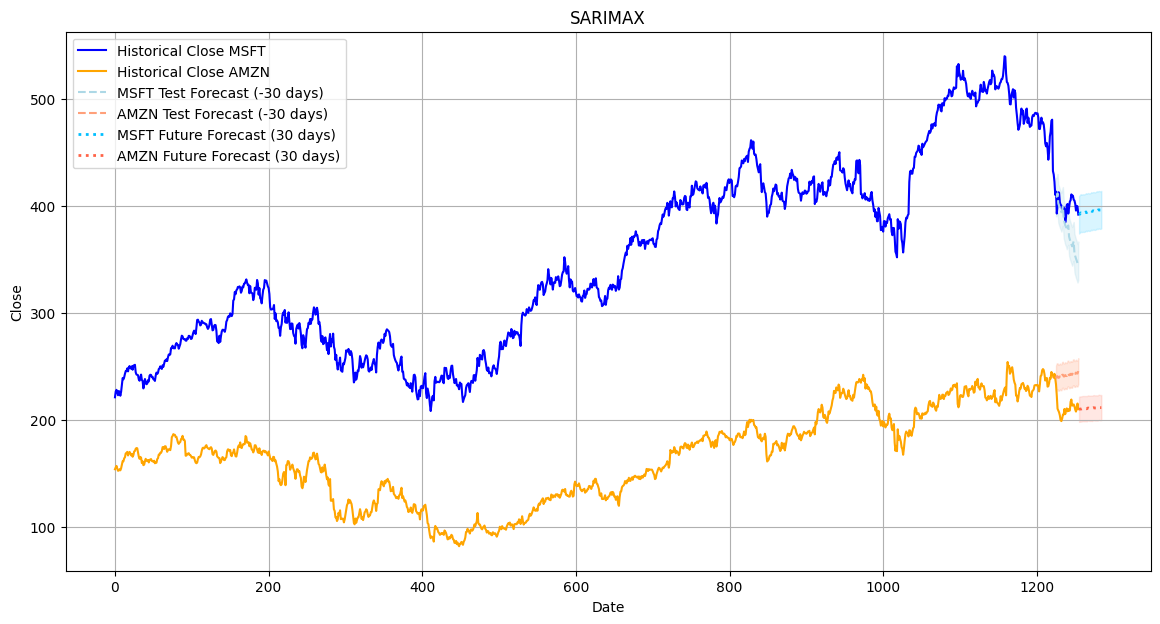

In [16]:

model="SARIMAX"
# 1. Fit Holt-Winters second model (with damped trend, additive seasonality, additive trending, and sesonal perios as one full year)

model_msft_test = SARIMAX(train_msft[usedColumn], exog=df_msft['Volume'][:-FORECAST_DAYS],order=(2,1,2),seasonal_order=(1,1,1,7))
fit_msft_test = model_msft_test.fit(disp=False)
model_amzn_test = SARIMAX(train_amzn[usedColumn], exog=df_amzn['Volume'][:-FORECAST_DAYS],order=(2,1,2),seasonal_order=(1,1,1,7))
fit_amzn_test = model_amzn_test.fit(disp=False)
# 2. Forecast last 30 days
forecast_msft_test = fit_msft_test.forecast(steps=FORECAST_DAYS,exog=df_msft['Volume'][-FORECAST_DAYS:])
forecast_amzn_test = fit_amzn_test.forecast(steps=FORECAST_DAYS,exog=df_amzn['Volume'][-FORECAST_DAYS:])

# 3. Align forecast index with test index
forecast_msft_test.index = test_msft.index
forecast_amzn_test.index = test_amzn.index

# 4. Calculating the errors using a def for test period
result_error = calculate_metrics(test_msft[usedColumn], forecast_msft_test,MSFT_Name,model)
all_metrics.append(result_error)
result_error = calculate_metrics(test_amzn[usedColumn], forecast_amzn_test,AMZN_Name,model)
all_metrics.append(result_error)

# 5. Creating confidence intervals for test period
resid_msft_test = train_msft[usedColumn] - fit_msft_test.fittedvalues
resid_amzn_test = train_amzn[usedColumn] - fit_amzn_test.fittedvalues
sigma_msft_test = resid_msft_test.std()
sigma_amzn_test = resid_amzn_test.std()
lower_msft_test = forecast_msft_test - z * sigma_msft_test
upper_msft_test = forecast_msft_test + z * sigma_msft_test
lower_amzn_test = forecast_amzn_test - z * sigma_amzn_test
upper_amzn_test = forecast_amzn_test + z * sigma_amzn_test

# 6. Refit wit full dataset to create a forecast for the next 30days
# Omiting exogenous since there is no future data for this component (this is used to plot, not to compare models)
model_msft_full = SARIMAX(df_msft[usedColumn],order=(2,1,2),seasonal_order=(1,1,1,7))
fit_msft_full = model_msft_full.fit(disp=False)
model_amzn_full = SARIMAX(df_amzn[usedColumn], order=(2,1,2),seasonal_order=(1,1,1,7))
fit_amzn_full = model_amzn_full.fit(disp=False)

# 7. Forecast next 30 days
##################Improvement 02!!
#forecast_msft_future = fit_msft_full.forecast(steps=FORECAST_DAYS,exog=df_msft['Volume'])
#forecast_amzn_future = fit_amzn_full.forecast(steps=FORECAST_DAYS,exog=df_amzn['Volume'])
forecast_msft_future = fit_msft_full.forecast(steps=FORECAST_DAYS)
forecast_amzn_future = fit_amzn_full.forecast(steps=FORECAST_DAYS)


# 8. Creating confidence intervals for forecast period
resid_msft_full = df_msft[usedColumn] - fit_msft_full.fittedvalues
resid_amzn_full = df_amzn[usedColumn] - fit_amzn_full.fittedvalues
sigma_msft_full = resid_msft_full.std()
sigma_amzn_full = resid_amzn_full.std()
lower_msft_future = forecast_msft_future - z * sigma_msft_full
upper_msft_future = forecast_msft_future + z * sigma_msft_full
lower_amzn_future = forecast_amzn_future - z * sigma_amzn_full
upper_amzn_future = forecast_amzn_future + z * sigma_amzn_full

# 6. Visualization
plt.figure(figsize=(14,7))
# plotting historical Data
plt.plot(df_msft.index, df_msft[usedColumn], label=f"Historical {usedColumn} MSFT", color="blue")
plt.plot(df_amzn.index, df_amzn[usedColumn], label=f"Historical {usedColumn} AMZN", color="orange")
# Plotting Test Forecast
plt.plot(forecast_msft_test.index, forecast_msft_test, linestyle='--', label=f'MSFT Test Forecast (-{FORECAST_DAYS} days)', color="lightblue")
plt.plot(forecast_amzn_test.index, forecast_amzn_test, linestyle='--', label=f'AMZN Test Forecast (-{FORECAST_DAYS} days)', color="lightsalmon")
# Ploting Test confidence intervals
plt.fill_between(forecast_msft_test.index, lower_msft_test, upper_msft_test,color="lightblue", alpha=0.25)
plt.fill_between(forecast_amzn_test.index, lower_amzn_test, upper_amzn_test,color="lightsalmon", alpha=0.25)
# Future forecasts
plt.plot(forecast_msft_future.index, forecast_msft_future,linestyle=':', linewidth=2, color="deepskyblue",label=f"MSFT Future Forecast ({FORECAST_DAYS} days)")
plt.plot(forecast_amzn_future.index, forecast_amzn_future,linestyle=':', linewidth=2, color="tomato",label=f"AMZN Future Forecast ({FORECAST_DAYS} days)")
# Future confidence intervals
plt.fill_between(forecast_msft_future.index, lower_msft_future, upper_msft_future,color="deepskyblue", alpha=0.15)
plt.fill_between(forecast_amzn_future.index, lower_amzn_future, upper_amzn_future,color="tomato", alpha=0.15)

plt.title("SARIMAX")
plt.xlabel("Date")
plt.ylabel(f"{usedColumn}")
plt.legend()
plt.grid(True)
plt.show()

XGBoost

MSFT Metrics
------------------------------------
Evaluation on Test Set MSFT:
MAE: 5.43, Relative MAE: 1.35%
MAPE: 1.35%
RMSE: 6.80, Relative RMSE: 1.70%
MSE: 46.25, Relative MSE: 0.03%
------------------------------------
AMZN Metrics
------------------------------------
Evaluation on Test Set AMZN:
MAE: 4.41, Relative MAE: 2.10%
MAPE: 2.09%
RMSE: 5.32, Relative RMSE: 2.53%
MSE: 28.26, Relative MSE: 0.06%
------------------------------------

MSFT Summary
Expected growth over horizon (%): 1.02
Forecast volatility (std of daily returns, %): 0.31
Forecast drift (price units per day): 0.0326

AMZN Summary
Expected growth over horizon (%): 1.97
Forecast volatility (std of daily returns, %): 0.36
Forecast drift (price units per day): 0.0383


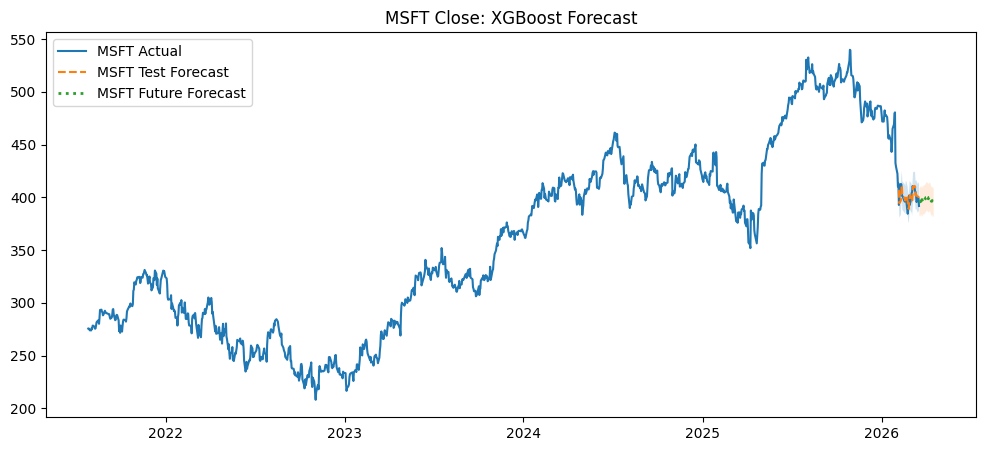

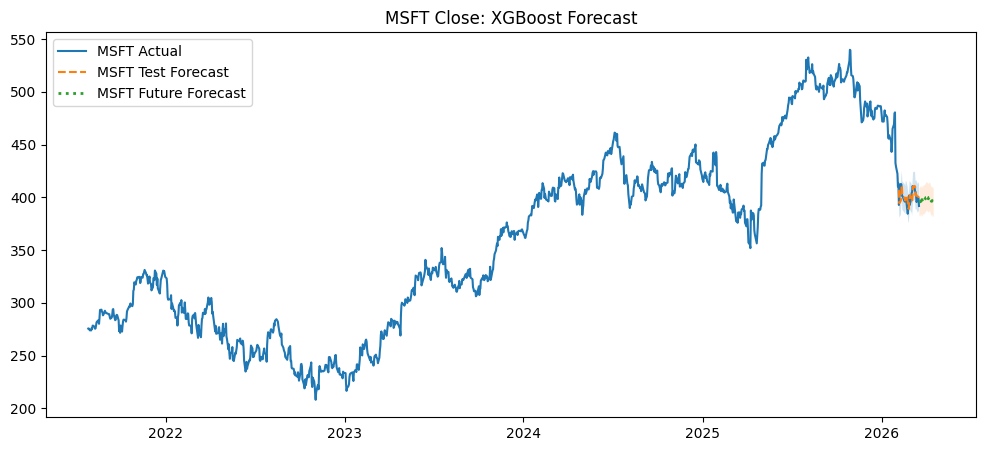

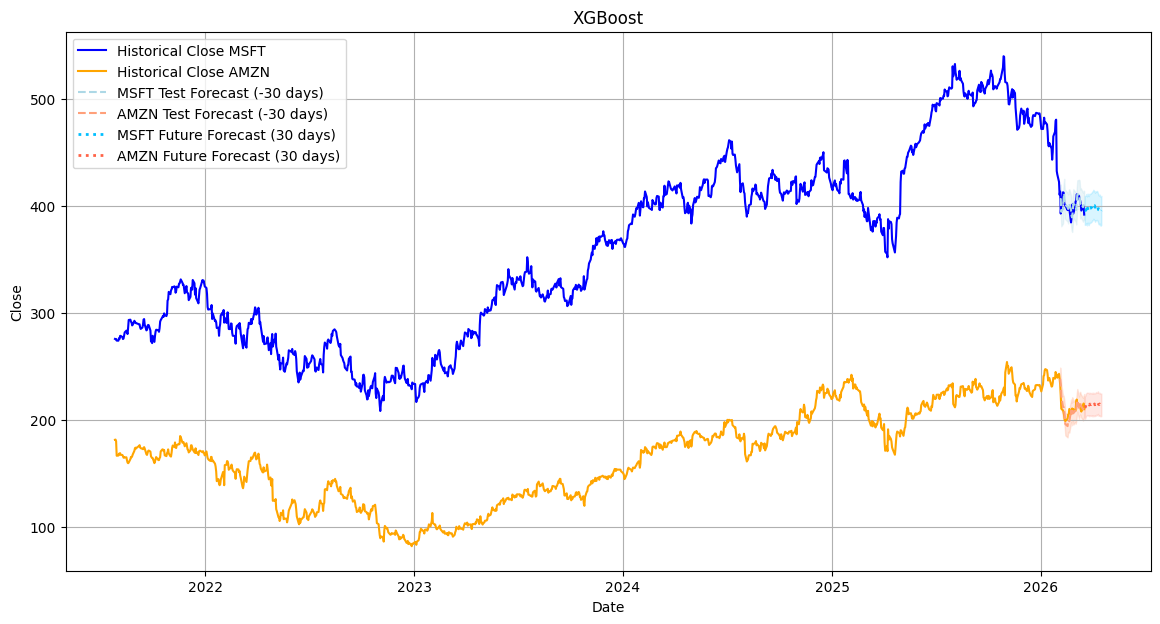

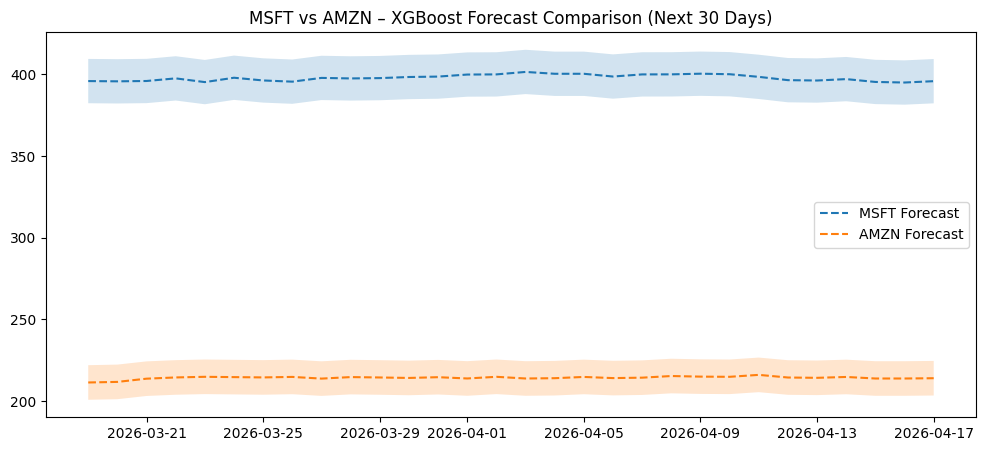

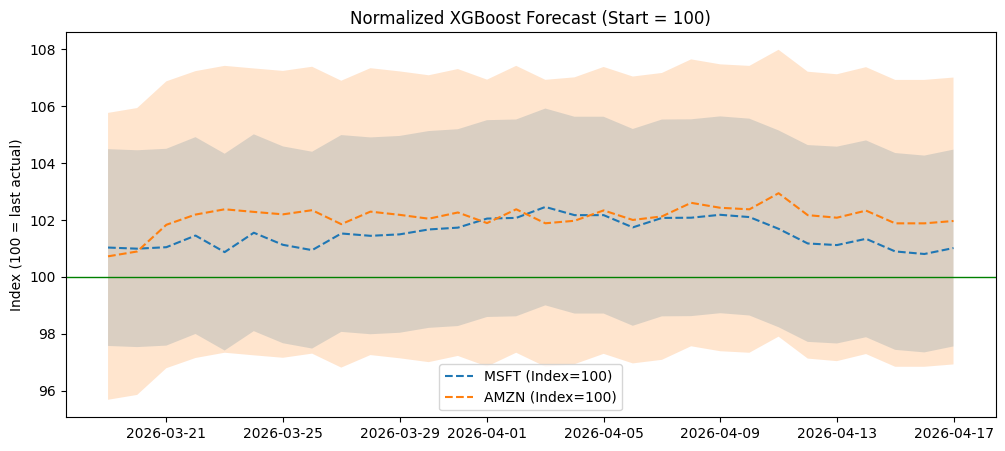

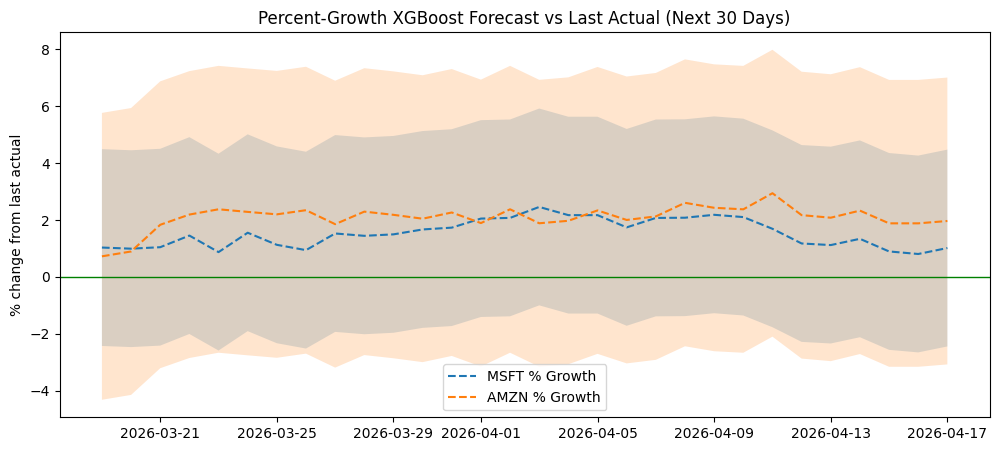

In [17]:
def CreateXGBoostModel_test(df_tmp):
  df_tmp = df_tmp.copy()
  df_tmp['Date'] = pd.to_datetime(df_tmp['Date'])
  df_tmp = df_tmp.sort_values('Date')
  df_tmp = df_tmp.set_index('Date')

  N_LAGS = FORECAST_DAYS

  for i in range(1, N_LAGS + 1):
        df_tmp[f'lag{i}'] = df_tmp[usedColumn].shift(i)

  df_tmp = df_tmp.dropna()
  lag_cols = [f'lag{i}' for i in range(1, N_LAGS + 1)]

  # 1. XGBoost forecast (using lag features)
  X = df_tmp[lag_cols]
  y = df_tmp[usedColumn]
  X_train, X_test = X.iloc[:-FORECAST_DAYS], X.iloc[-FORECAST_DAYS:]
  y_train, y_test = y.iloc[:-FORECAST_DAYS], y.iloc[-FORECAST_DAYS:]
  model_tmp = XGBRegressor(n_estimators = 300, learning_rate = 0.05, max_depth = 4,objective='reg:squarederror')
  model_tmp.fit(X_train, y_train)
  forecast_tmp =  pd.Series(model_tmp.predict(X_test), index=y_test.index)

  model_tmp_full = XGBRegressor(n_estimators = 300, learning_rate = 0.05, max_depth = 4,objective='reg:squarederror')
  model_tmp_full.fit(X, y)

  #------------------------------------------------------

  # -----------------------------------
# 7. Recursive future forecast (next 30 points)
# -----------------------------------
  #last_window = df_tmp[usedColumn].iloc[-FORECAST_DAYS:].values.tolist()
  last_window = df_tmp[usedColumn].iloc[-N_LAGS:].values.tolist()
  future_preds = []

  for _ in range(FORECAST_DAYS):
      # Most recent lag first: lag_1 = yesterday, lag_2 = two days ago, etc.
        x_input = np.array([last_window[::-1]])
        next_pred = model_tmp_full.predict(x_input)[0]
        future_preds.append(next_pred)
        last_window.append(next_pred)
        last_window = last_window[-N_LAGS:]


  # Create future index
  last_date = df_tmp.index[-1]
  future_index = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=FORECAST_DAYS, freq="D")
  future_forecast = pd.Series(future_preds, index=future_index)
  #return df_tmp model_tmp, forecast_tmp, model_tmp_full, future_forecast
  return df_tmp, y_train, y_test, forecast_tmp, future_forecast


def xgb_forecast_metrics(actual_series: pd.Series, future_forecast: pd.Series):
    last_price = actual_series.iloc[-1]
    final_price = future_forecast.iloc[-1]
    growth_pct = (final_price / last_price - 1.0) * 100.0
    vol_pct = np.std(future_forecast.pct_change().dropna()) * 100.0
    return growth_pct, vol_pct


def xgb_forecast_drift(future_forecast: pd.Series):
    y = future_forecast.values
    x = np.arange(len(y))
    slope = np.polyfit(x, y, 1)[0]
    return slope


def print_xgb_summary(name: str, actual_series: pd.Series, future_forecast: pd.Series):
    growth, vol = xgb_forecast_metrics(actual_series, future_forecast)
    drift = xgb_forecast_drift(future_forecast)
    print(f"\n{name} Summary")
    print(f"Expected growth over horizon (%): {growth:.2f}")
    print(f"Forecast volatility (std of daily returns, %): {vol:.2f}")
    print(f"Forecast drift (price units per day): {drift:.4f}")



model="XGBoost"

#model_msft_test, forecast_msft_test, model_msft_future, forecast_msft_future  = CreateXGBoostModel_test(df_msft)
df_msft_clean, ytrain_msft, ytest_msft, forecast_msft_test, forecast_msft_future = CreateXGBoostModel_test(df_msft)
result_error = calculate_metrics(ytest_msft, forecast_msft_test, MSFT_Name, model)
all_metrics.append(result_error)

####df_msft_clean, model_msft_test, forecast_msft_test, model_msft_future, forecast_msft_future = CreateXGBoostModel_test(df_msft)
####result_error = calculate_metrics(test_msft[usedColumn], forecast_msft_test,MSFT_Name,model)
####all_metrics.append(result_error)

#model_amzn_test, forecast_amzn_test, model_amzn_future, forecast_amzn_future = CreateXGBoostModel_test(df_amzn)
####df_amzn_clean, model_amzn_test, forecast_amzn_test, model_amzn_future, forecast_amzn_future = CreateXGBoostModel_test(df_amzn)
####result_error = calculate_metrics(test_amzn[usedColumn], forecast_amzn_test,AMZN_Name,model)
####all_metrics.append(result_error)
df_amzn_clean, ytrain_amzn, ytest_amzn, forecast_amzn_test, forecast_amzn_future = CreateXGBoostModel_test(df_amzn)
result_error = calculate_metrics(ytest_amzn, forecast_amzn_test, AMZN_Name, model)
all_metrics.append(result_error)


forecast_comp_amzn_future=forecast_amzn_future
forecast_comp_msft_future=forecast_msft_future
####
# 5. Creating confidence intervals for test period
resid_msft_test = ytest_msft - forecast_msft_test
resid_amzn_test = ytest_amzn - forecast_amzn_test
sigma_msft_test = resid_msft_test.std()
sigma_amzn_test = resid_amzn_test.std()
lower_msft_test = forecast_msft_test - z * sigma_msft_test
upper_msft_test = forecast_msft_test + z * sigma_msft_test
lower_amzn_test = forecast_amzn_test - z * sigma_amzn_test
upper_amzn_test = forecast_amzn_test + z * sigma_amzn_test

# Future intervals: use test residual std as approximate future uncertainty
lower_msft_future = forecast_msft_future - z * sigma_msft_test
upper_msft_future = forecast_msft_future + z * sigma_msft_test
lower_amzn_future = forecast_amzn_future - z * sigma_amzn_test
upper_amzn_future = forecast_amzn_future + z * sigma_amzn_test

# 5. Creating confidence intervals for test period
####resid_msft_test = train_msft[usedColumn] - forecast_msft_test
####resid_amzn_test = train_amzn[usedColumn] - forecast_amzn_test
####sigma_msft_test = resid_msft_test.std()
####sigma_amzn_test = resid_amzn_test.std()
####lower_msft_test = forecast_msft_test - z * sigma_msft_test
####upper_msft_test = forecast_msft_test + z * sigma_msft_test
####lower_amzn_test = forecast_amzn_test - z * sigma_amzn_test
####upper_amzn_test = forecast_amzn_test + z * sigma_amzn_test

# 8. Creating confidence intervals for forecast period
####resid_msft_full = df_msft[usedColumn] - forecast_msft_future
####resid_amzn_full = df_amzn[usedColumn] - forecast_amzn_future
####sigma_msft_full = resid_msft_full.std()
####sigma_amzn_full = resid_amzn_full.std()
####lower_msft_future = forecast_msft_future - z * sigma_msft_full
####upper_msft_future = forecast_msft_future + z * sigma_msft_full
####lower_amzn_future = forecast_amzn_future - z * sigma_amzn_full
####upper_amzn_future = forecast_amzn_future + z * sigma_amzn_full

print_xgb_summary("MSFT", df_msft_clean[usedColumn], forecast_msft_future)
print_xgb_summary("AMZN", df_amzn_clean[usedColumn], forecast_amzn_future)

# 6. Visualization
# Individual plots
plt.figure(figsize=(12, 5))
plt.plot(df_msft_clean.index, df_msft_clean[usedColumn], label="MSFT Actual")
plt.plot(forecast_msft_test.index, forecast_msft_test, "--", label="MSFT Test Forecast")
plt.fill_between(forecast_msft_test.index, lower_msft_test, upper_msft_test, alpha=0.2)
plt.plot(forecast_msft_future.index, forecast_msft_future, ":", linewidth=2, label="MSFT Future Forecast")
plt.fill_between(forecast_msft_future.index, lower_msft_future, upper_msft_future, alpha=0.15)
plt.title("MSFT Close: XGBoost Forecast")
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(df_msft_clean.index, df_msft_clean[usedColumn], label="MSFT Actual")
plt.plot(forecast_msft_test.index, forecast_msft_test, "--", label="MSFT Test Forecast")
plt.fill_between(forecast_msft_test.index, lower_msft_test, upper_msft_test, alpha=0.2)
plt.plot(forecast_msft_future.index, forecast_msft_future, ":", linewidth=2, label="MSFT Future Forecast")
plt.fill_between(forecast_msft_future.index, lower_msft_future, upper_msft_future, alpha=0.15)
plt.title("MSFT Close: XGBoost Forecast")
plt.legend()
plt.show()


plt.figure(figsize=(14,7))
# plotting historical Data
###plt.plot(df_msft.index, df_msft[usedColumn], label=f"Historical {usedColumn} MSFT", color="blue")
###plt.plot(df_amzn.index, df_amzn[usedColumn], label=f"Historical {usedColumn} AMZN", color="orange")
plt.plot(df_msft_clean.index, df_msft_clean[usedColumn], label=f"Historical {usedColumn} MSFT", color="blue")
plt.plot(df_amzn_clean.index, df_amzn_clean[usedColumn], label=f"Historical {usedColumn} AMZN", color="orange")
# Plotting Test Forecast
plt.plot(forecast_msft_test.index, forecast_msft_test, linestyle='--', label=f'MSFT Test Forecast (-{FORECAST_DAYS} days)', color="lightblue")
plt.plot(forecast_amzn_test.index, forecast_amzn_test, linestyle='--', label=f'AMZN Test Forecast (-{FORECAST_DAYS} days)', color="lightsalmon")
# Ploting Test confidence intervals
plt.fill_between(forecast_msft_test.index, lower_msft_test, upper_msft_test,color="lightblue", alpha=0.25)
plt.fill_between(forecast_amzn_test.index, lower_amzn_test, upper_amzn_test,color="lightsalmon", alpha=0.25)
# Future forecasts
plt.plot(forecast_msft_future.index, forecast_msft_future,linestyle=':', linewidth=2, color="deepskyblue",label=f"MSFT Future Forecast ({FORECAST_DAYS} days)")
plt.plot(forecast_amzn_future.index, forecast_amzn_future,linestyle=':', linewidth=2, color="tomato",label=f"AMZN Future Forecast ({FORECAST_DAYS} days)")
# Future confidence intervals
plt.fill_between(forecast_msft_future.index, lower_msft_future, upper_msft_future,color="deepskyblue", alpha=0.15)
plt.fill_between(forecast_amzn_future.index, lower_amzn_future, upper_amzn_future,color="tomato", alpha=0.15)
plt.title("XGBoost")
plt.xlabel("Date")
plt.ylabel(f"{usedColumn}")
plt.legend()
plt.grid(True)
plt.show()

# Comparing forecast
plt.figure(figsize=(12, 5))

plt.plot(forecast_msft_future.index, forecast_msft_future, "--", label="MSFT Forecast")
plt.fill_between(
    forecast_msft_future.index,
    lower_msft_future,
    upper_msft_future,
    alpha=0.2
)

plt.plot(forecast_amzn_future.index, forecast_amzn_future, "--", label="AMZN Forecast")
plt.fill_between(
    forecast_amzn_future.index,
    lower_amzn_future,
    upper_amzn_future,
    alpha=0.2
)

plt.title(f"MSFT vs AMZN – XGBoost Forecast Comparison (Next {FORECAST_DAYS} Days)")
plt.legend()
plt.show()


# normalized Forecast plot

msft_base = df_msft_clean[usedColumn].iloc[-1]
amzn_base = df_amzn_clean[usedColumn].iloc[-1]

msft_future_xgb = pd.DataFrame({
    "ds": forecast_msft_future.index,
    "forecast": forecast_msft_future.values,
    "lower": lower_msft_future.values,
    "upper": upper_msft_future.values
})

amzn_future_xgb = pd.DataFrame({
    "ds": forecast_amzn_future.index,
    "forecast": forecast_amzn_future.values,
    "lower": lower_amzn_future.values,
    "upper": upper_amzn_future.values
})

msft_future_xgb["idx100"] = (msft_future_xgb["forecast"] / msft_base) * 100
msft_future_xgb["idx100_lo"] = (msft_future_xgb["lower"] / msft_base) * 100
msft_future_xgb["idx100_hi"] = (msft_future_xgb["upper"] / msft_base) * 100

amzn_future_xgb["idx100"] = (amzn_future_xgb["forecast"] / amzn_base) * 100
amzn_future_xgb["idx100_lo"] = (amzn_future_xgb["lower"] / amzn_base) * 100
amzn_future_xgb["idx100_hi"] = (amzn_future_xgb["upper"] / amzn_base) * 100

plt.figure(figsize=(12, 5))
plt.axhline(100, linewidth=1, color="green")

plt.plot(msft_future_xgb["ds"], msft_future_xgb["idx100"], "--", label="MSFT (Index=100)")
plt.fill_between(msft_future_xgb["ds"], msft_future_xgb["idx100_lo"], msft_future_xgb["idx100_hi"], alpha=0.2)

plt.plot(amzn_future_xgb["ds"], amzn_future_xgb["idx100"], "--", label="AMZN (Index=100)")
plt.fill_between(amzn_future_xgb["ds"], amzn_future_xgb["idx100_lo"], amzn_future_xgb["idx100_hi"], alpha=0.2)

plt.title("Normalized XGBoost Forecast (Start = 100)")
plt.ylabel("Index (100 = last actual)")
plt.legend()
plt.show()

# Percent growth forecast plot
msft_future_xgb["pct"] = (msft_future_xgb["forecast"] / msft_base - 1.0) * 100
msft_future_xgb["pct_lo"] = (msft_future_xgb["lower"] / msft_base - 1.0) * 100
msft_future_xgb["pct_hi"] = (msft_future_xgb["upper"] / msft_base - 1.0) * 100

amzn_future_xgb["pct"] = (amzn_future_xgb["forecast"] / amzn_base - 1.0) * 100
amzn_future_xgb["pct_lo"] = (amzn_future_xgb["lower"] / amzn_base - 1.0) * 100
amzn_future_xgb["pct_hi"] = (amzn_future_xgb["upper"] / amzn_base - 1.0) * 100

plt.figure(figsize=(12, 5))
plt.axhline(0, linewidth=1, color="green")

plt.plot(msft_future_xgb["ds"], msft_future_xgb["pct"], "--", label="MSFT % Growth")
plt.fill_between(msft_future_xgb["ds"], msft_future_xgb["pct_lo"], msft_future_xgb["pct_hi"], alpha=0.2)

plt.plot(amzn_future_xgb["ds"], amzn_future_xgb["pct"], "--", label="AMZN % Growth")
plt.fill_between(amzn_future_xgb["ds"], amzn_future_xgb["pct_lo"], amzn_future_xgb["pct_hi"], alpha=0.2)

plt.title(f"Percent-Growth XGBoost Forecast vs Last Actual (Next {FORECAST_DAYS} Days)")
plt.ylabel("% change from last actual")
plt.legend()
plt.show()




          ds         y
0 2021-03-19  5.398319
1 2021-03-22  5.422508
2 2021-03-23  5.429224
3 2021-03-24  5.420260
4 2021-03-25  5.406921


18:50:19 - cmdstanpy - INFO - Chain [1] start processing
18:50:20 - cmdstanpy - INFO - Chain [1] done processing
18:50:20 - cmdstanpy - INFO - Chain [1] start processing
18:50:21 - cmdstanpy - INFO - Chain [1] done processing
18:50:21 - cmdstanpy - INFO - Chain [1] start processing


MSFT Metrics
------------------------------------
Evaluation on Test Set MSFT:
MAE: 42.49, Relative MAE: 10.59%
MAPE: 10.62%
RMSE: 44.23, Relative RMSE: 11.02%
MSE: 1956.23, Relative MSE: 1.21%
------------------------------------
AMZN Metrics
------------------------------------
Evaluation on Test Set AMZN:
MAE: 15.20, Relative MAE: 7.23%
MAPE: 7.36%
RMSE: 19.34, Relative RMSE: 9.20%
MSE: 373.87, Relative MSE: 0.85%
------------------------------------


18:50:22 - cmdstanpy - INFO - Chain [1] done processing
18:50:22 - cmdstanpy - INFO - Chain [1] start processing
18:50:23 - cmdstanpy - INFO - Chain [1] done processing


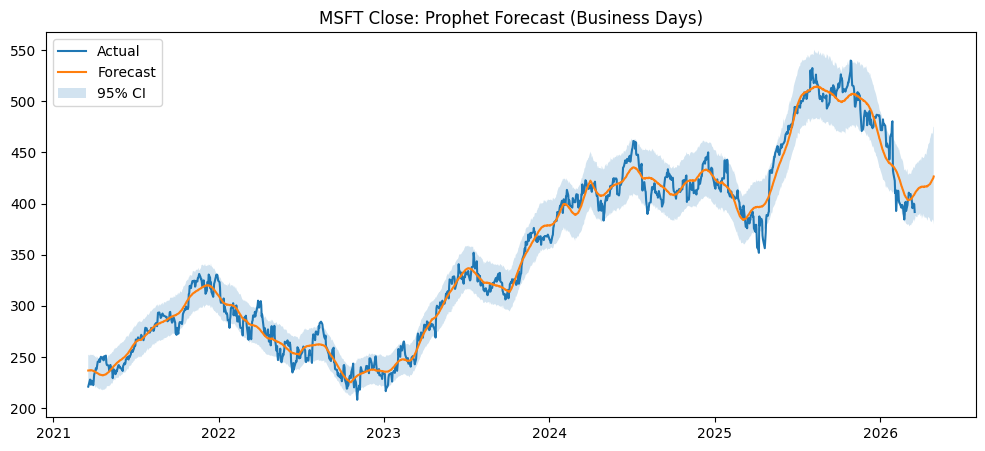

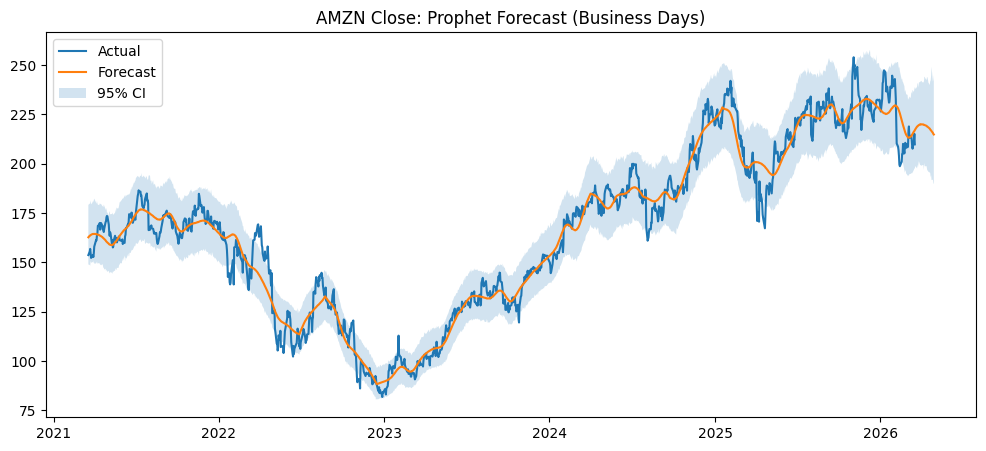

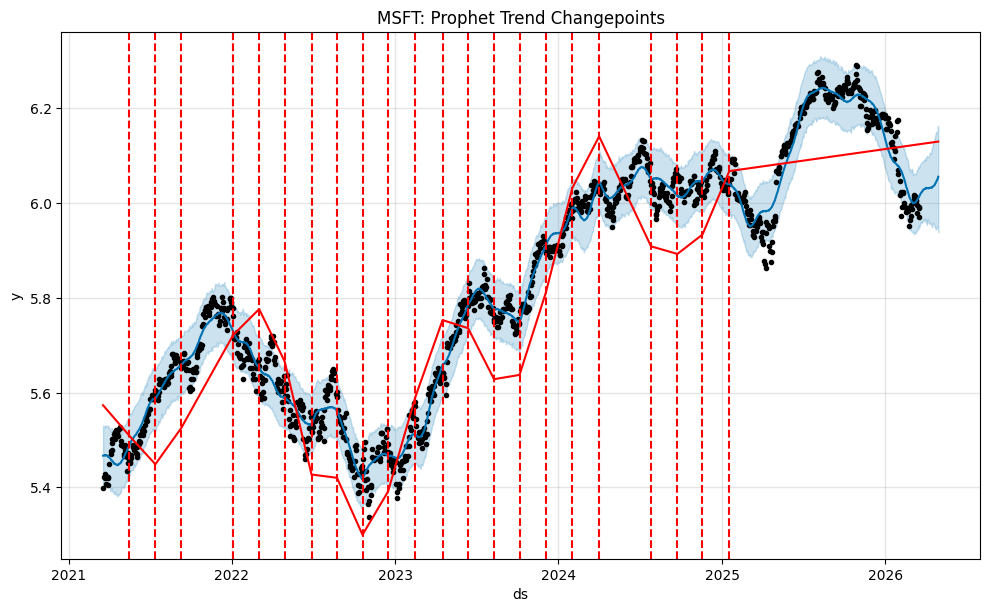

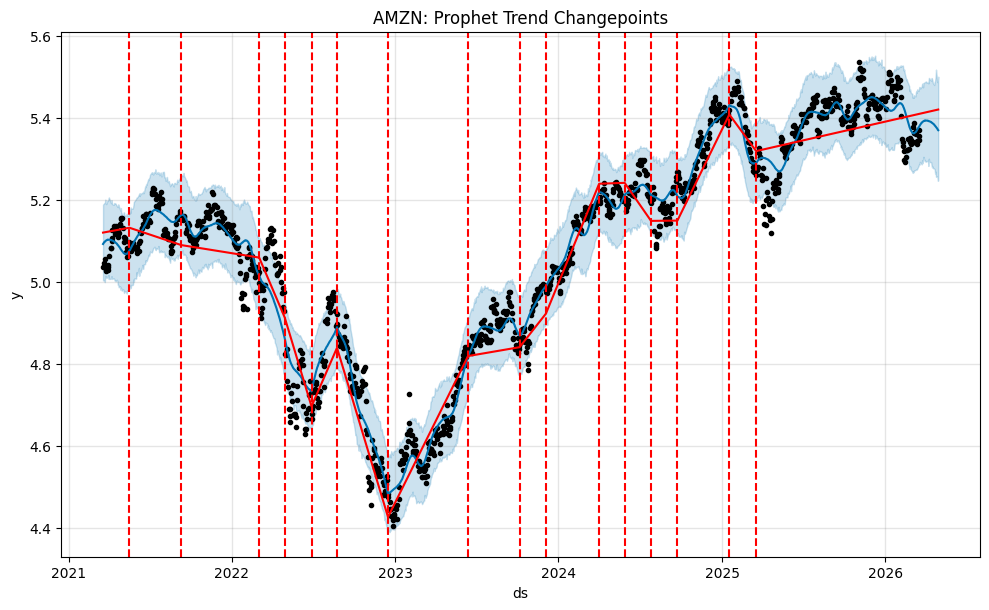

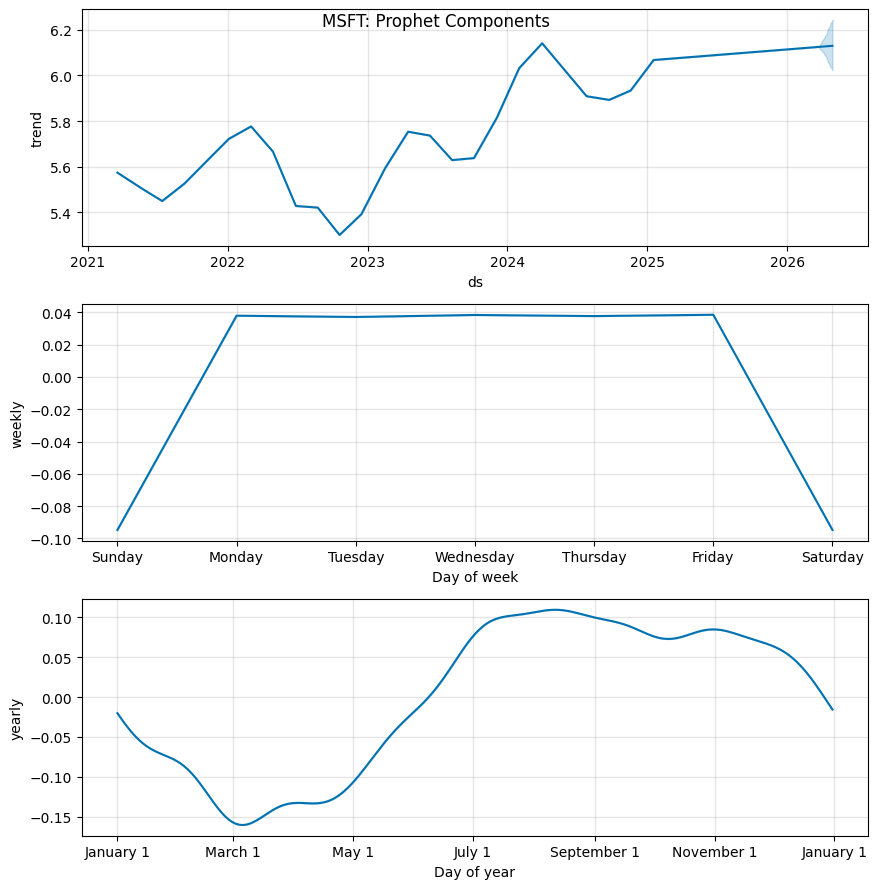

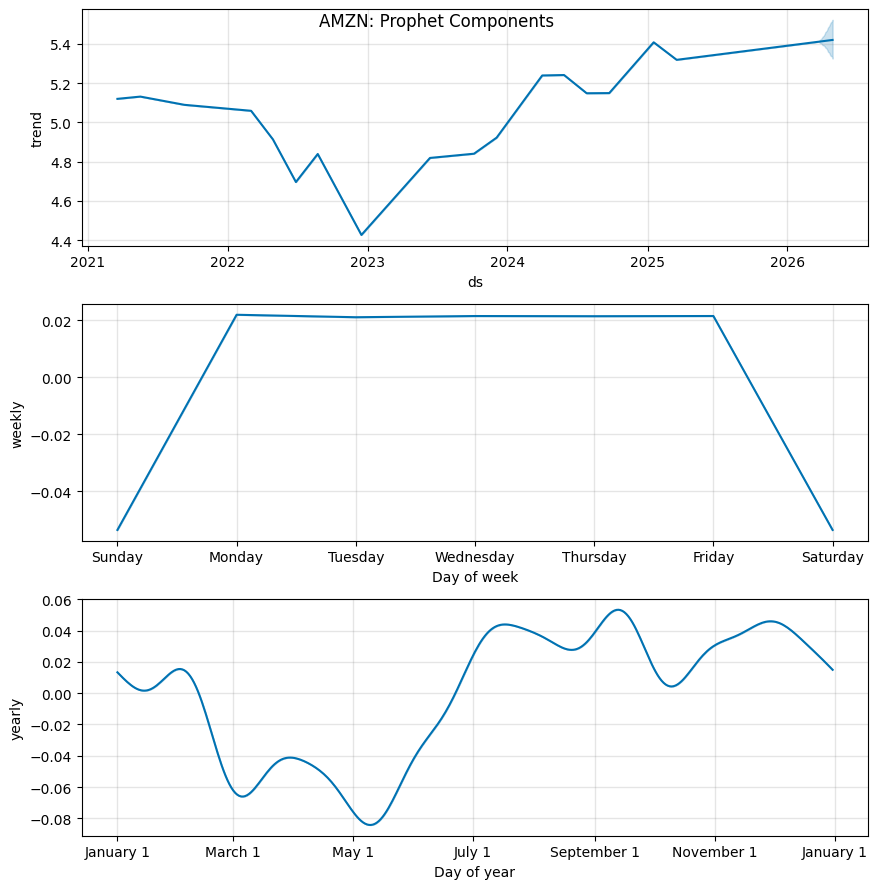

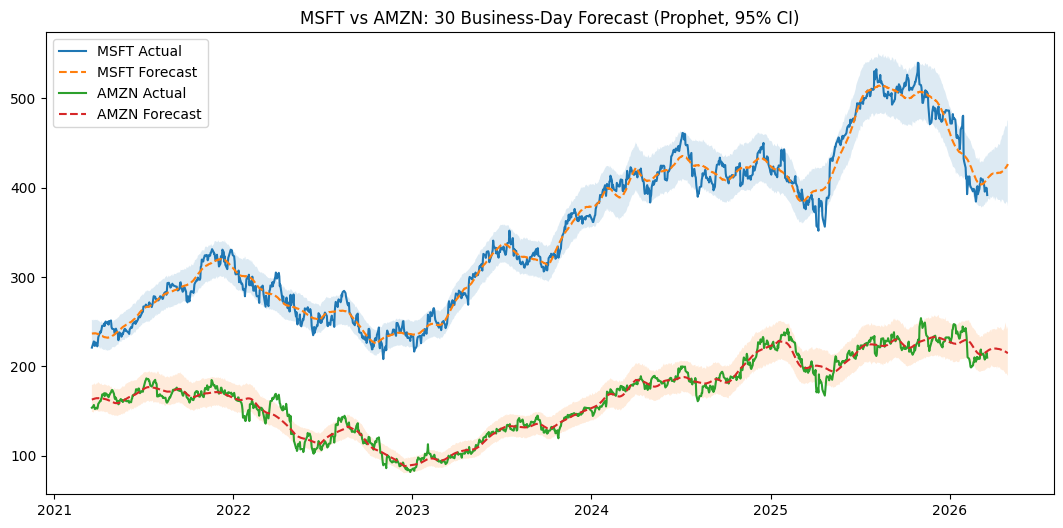


MSFT Summary
Expected growth over horizon (%): 8.87
Forecast volatility (std of daily returns, %): 0.30
Forecast drift (price units per business day): 0.2036

AMZN Summary
Expected growth over horizon (%): 2.38
Forecast volatility (std of daily returns, %): 0.37
Forecast drift (price units per business day): 0.0743


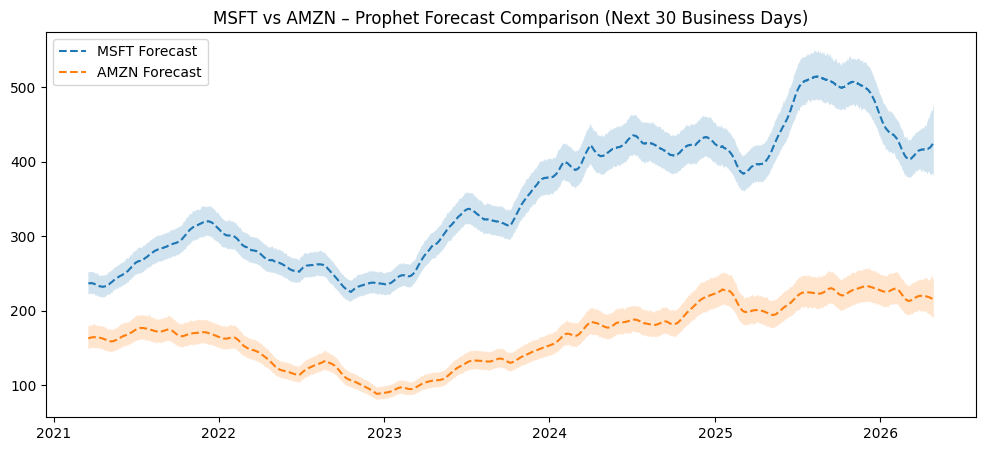

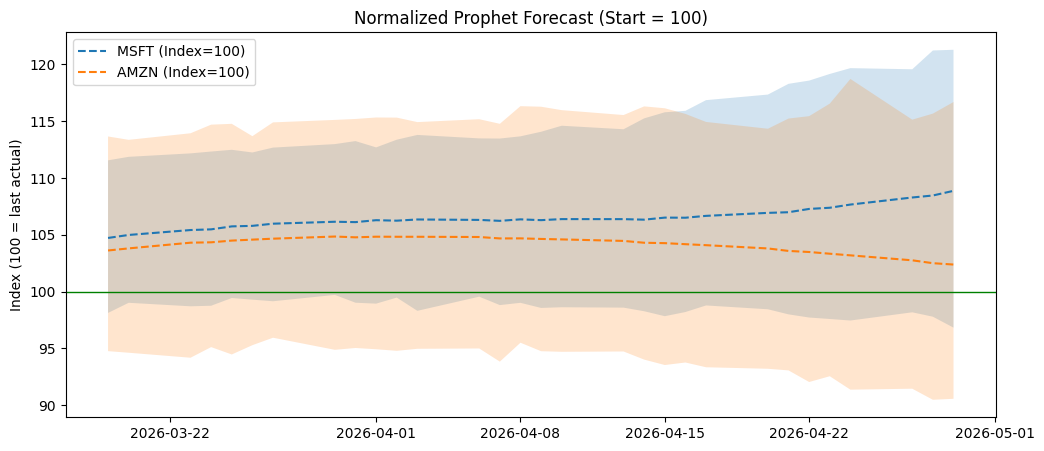

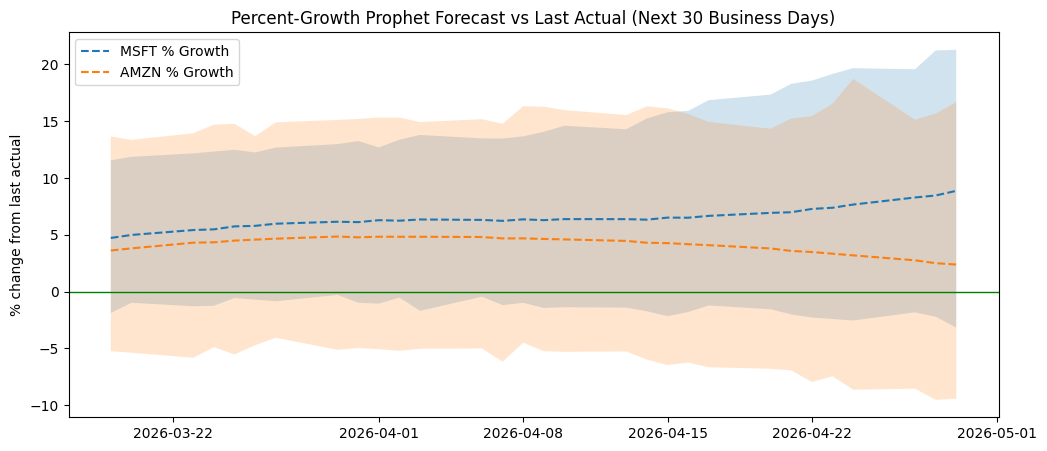

In [18]:
# Using Prophet to forecast

# Set your files
FILE_MSFT = data_msft_file
FILE_AMZN = data_amzn_file
model="Prophet"
#FORECAST_DAYS = 30
INTERVAL_WIDTH = 0.95
useLog = True

def prophet_test_forecast(dfp: pd.DataFrame, test_days: int, interval_width: float = 0.95):
    # Split into train and test
    train = dfp.iloc[:-test_days].copy()
    test = dfp.iloc[-test_days:].copy()

    # Fit Prophet only on train
    m = Prophet(
        daily_seasonality=False,
        weekly_seasonality=True,
        yearly_seasonality=True,
        seasonality_mode="additive",
        interval_width=interval_width,
    )
    m.fit(train)

    # Forecast exactly the test horizon
    future = m.make_future_dataframe(periods=test_days, freq="B")
    fc = m.predict(future)

    # Keep only the forecasted test period
    fc_test = fc[fc["ds"].isin(test["ds"])][["ds", "yhat", "yhat_lower", "yhat_upper"]].copy()

    # Convert back from log if needed
    test_actual = test.copy()

    if useLog:
        test_actual["price"] = np.exp(test_actual["y"])
        fc_test["yhat_price"] = np.exp(fc_test["yhat"])
        fc_test["yhat_lower_price"] = np.exp(fc_test["yhat_lower"])
        fc_test["yhat_upper_price"] = np.exp(fc_test["yhat_upper"])
    else:
        test_actual["price"] = test_actual["y"]
        fc_test["yhat_price"] = fc_test["yhat"]
        fc_test["yhat_lower_price"] = fc_test["yhat_lower"]
        fc_test["yhat_upper_price"] = fc_test["yhat_upper"]

    compare = pd.merge(
        test_actual[["ds", "price"]],
        fc_test[["ds", "yhat_price", "yhat_lower_price", "yhat_upper_price"]],
        on="ds", how="inner")

    return m, train, test_actual, fc_test, compare



def load_price_for_prophet(file_path: str) -> pd.DataFrame:
    # Loads files with columns: Date, Close (fixed) and eturns Prophet-ready df with columns: ds, y
    # Uses log(Close) to stabilize variance.
    df = pd.read_csv(file_path)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date")
    df = df.bfill()
    df = df.dropna(how="any")

    dfp = df[["Date", "Close"]].rename(columns={"Date": "ds", "Close": "y"}).copy()
    dfp["y"] = dfp["y"].astype(float)

    # Keep only business days if needed
    dfp = dfp[dfp["ds"].dt.dayofweek < 5].copy()

    # Log transform for smoother trend learning if useLog=True
    if useLog:
      dfp["y"] = np.log(dfp["y"])
    return dfp


def fit_and_forecast_prophet(dfp: pd.DataFrame, periods: int, interval_width: float = 0.95):
    # Fits Prophet on log (close) and forecasts forward on business days.
    # Returns: model (Prophet), actual_df with columns ds, price,
    # forecast_df with ds, yhat_price, yhat_lower_price, yhat_upper_price
    m = Prophet(
        daily_seasonality=False, # Since basic model os P(t) = P(t-1)+e
        weekly_seasonality=True, # Since data has a weekly basis
        yearly_seasonality=True, # Includes seasonality
        seasonality_mode="additive",
        interval_width=interval_width,
    )
    # Fit the model
    m.fit(dfp)

    # Forecasting
    future = m.make_future_dataframe(periods=periods, freq="B")
    fc = m.predict(future)

    # Convert from log space back to price space if useLog=True
    actual = dfp.copy()
    if useLog:
        actual["price"] = np.exp(actual["y"])
    else:
        actual["price"] = actual["y"]

    fc = fc.copy()
    if useLog:
      fc["yhat_price"] = np.exp(fc["yhat"])
      fc["yhat_lower_price"] = np.exp(fc["yhat_lower"])
      fc["yhat_upper_price"] = np.exp(fc["yhat_upper"])
    else:
        fc["yhat_price"] = fc["yhat"]
        fc["yhat_lower_price"] = fc["yhat_lower"]
        fc["yhat_upper_price"] = fc["yhat_upper"]

    return m, actual, fc

# Plot a single prophet graphic
def plot_single_prophet(actual: pd.DataFrame, fc: pd.DataFrame, title: str):
    plt.figure(figsize=(12, 5))
    plt.plot(actual["ds"], actual["price"], label="Actual")
    plt.plot(fc["ds"], fc["yhat_price"], label="Forecast")
    plt.fill_between(
        fc["ds"],
        fc["yhat_lower_price"],
        fc["yhat_upper_price"],
        alpha=0.2,
        label=f"{int(INTERVAL_WIDTH*100)}% CI",
    )
    plt.title(title)
    plt.legend()
    plt.show()

# Plot to show changepoints (similar to inflexion points)
def plot_changepoints(model: Prophet, fc: pd.DataFrame, title: str):
    fig = model.plot(fc)
    add_changepoints_to_plot(fig.gca(), model, fc)
    plt.title(title)
    plt.show()

# Plot each component of the model (Trend and seasons)
def plot_components(model: Prophet, fc: pd.DataFrame, title: str):
    fig = model.plot_components(fc)
    fig.suptitle(title)
    plt.show()


def forecast_metrics(actual: pd.DataFrame, fc: pd.DataFrame):
    # Simple cross-company metrics over the forecast horizon.
    # Growth is based on last actual vs last forecast point.
    #Volatility is std dev of forecast daily returns (in percent).

    last_price = actual["price"].iloc[-1]
    final_price = fc["yhat_price"].iloc[-1]

    growth_pct = (final_price / last_price - 1.0) * 100.0
    vol_pct = np.std(fc["yhat_price"].pct_change().dropna()) * 100.0

    return growth_pct, vol_pct


def forecast_drift(fc: pd.DataFrame):
    # Drift as the slope of yhat_price over time steps.
    # Units: price change per business day.

    y = fc["yhat_price"].values
    x = np.arange(len(y))
    slope = np.polyfit(x, y, 1)[0]
    return slope

# Prints a brief description of the forecast horizon.
def print_summary(name: str, actual: pd.DataFrame, fc: pd.DataFrame):
    growth, vol = forecast_metrics(actual, fc)
    drift = forecast_drift(fc)

    print(f"\n{name} Summary")
    print(f"Expected growth over horizon (%): {growth:.2f}")
    print(f"Forecast volatility (std of daily returns, %): {vol:.2f}")
    print(f"Forecast drift (price units per business day): {drift:.4f}")

# Calling the functions
# Load data
msft_dfp = load_price_for_prophet(data_msft_file)
amzn_dfp = load_price_for_prophet(data_amzn_file)

print(msft_dfp.head())


msft_test_model, msft_train, msft_test_actual, msft_fc_test, msft_compare = prophet_test_forecast(
    msft_dfp, FORECAST_DAYS, INTERVAL_WIDTH)

amzn_test_model, amzn_train, amzn_test_actual, amzn_fc_test, amzn_compare = prophet_test_forecast(
    amzn_dfp, FORECAST_DAYS, INTERVAL_WIDTH)

result_error = calculate_metrics(
    msft_compare["price"], msft_compare["yhat_price"],MSFT_Name,model)
all_metrics.append(result_error)
result_error = calculate_metrics(
    amzn_compare["price"], amzn_compare["yhat_price"],AMZN_Name,model)
all_metrics.append(result_error)

# Fit and forecast
msft_model, msft_actual, msft_fc = fit_and_forecast_prophet(msft_dfp, FORECAST_DAYS, INTERVAL_WIDTH)
amzn_model, amzn_actual, amzn_fc = fit_and_forecast_prophet(amzn_dfp, FORECAST_DAYS, INTERVAL_WIDTH)

# 1) Individual forecast plots
plot_single_prophet(msft_actual, msft_fc, "MSFT Close: Prophet Forecast (Business Days)")
plot_single_prophet(amzn_actual, amzn_fc, "AMZN Close: Prophet Forecast (Business Days)")

# 2) Changepoints visualization
plot_changepoints(msft_model, msft_fc, "MSFT: Prophet Trend Changepoints")
plot_changepoints(amzn_model, amzn_fc, "AMZN: Prophet Trend Changepoints")

# 3) Component decomposition (trend, weekly, yearly)
plot_components(msft_model, msft_fc, "MSFT: Prophet Components")
plot_components(amzn_model, amzn_fc, "AMZN: Prophet Components")

# 4) Combined plot
plt.figure(figsize=(13, 6))

plt.plot(msft_actual["ds"], msft_actual["price"], label="MSFT Actual")
plt.plot(msft_fc["ds"], msft_fc["yhat_price"], "--", label="MSFT Forecast")
plt.fill_between(msft_fc["ds"], msft_fc["yhat_lower_price"], msft_fc["yhat_upper_price"], alpha=0.15)

plt.plot(amzn_actual["ds"], amzn_actual["price"], label="AMZN Actual")
plt.plot(amzn_fc["ds"], amzn_fc["yhat_price"], "--", label="AMZN Forecast")
plt.fill_between(amzn_fc["ds"], amzn_fc["yhat_lower_price"], amzn_fc["yhat_upper_price"], alpha=0.15)

plt.title(f"MSFT vs AMZN: {FORECAST_DAYS} Business-Day Forecast (Prophet, {int(INTERVAL_WIDTH*100)}% CI)")
plt.legend()
plt.show()

# 5) Cross-company metrics and forecast drift
print_summary("MSFT", msft_actual, msft_fc)
print_summary("AMZN", amzn_actual, amzn_fc)

# 6) Forecast-only comparison plot (Prophet outputs only)
plt.figure(figsize=(12, 5))

# MSFT forecast
plt.plot(msft_fc["ds"], msft_fc["yhat_price"], "--", label="MSFT Forecast")
plt.fill_between(
    msft_fc["ds"],
    msft_fc["yhat_lower_price"],
    msft_fc["yhat_upper_price"],
    alpha=0.2
)

# AMZN forecast
plt.plot(amzn_fc["ds"], amzn_fc["yhat_price"], "--", label="AMZN Forecast")
plt.fill_between(
    amzn_fc["ds"],
    amzn_fc["yhat_lower_price"],
    amzn_fc["yhat_upper_price"],
    alpha=0.2
)

plt.title(f"MSFT vs AMZN – Prophet Forecast Comparison (Next {FORECAST_DAYS} Business Days)")
plt.legend()
plt.show()

# 7) Normalized forecast (both start at 100) + Percent-growth forecast plot
# this allows to compare in a normalized scale, so the comparisson is even.

# Helper: keep only the forecast horizon (exclude history)
msft_future = msft_fc[msft_fc["ds"] > msft_actual["ds"].max()].copy()
amzn_future = amzn_fc[amzn_fc["ds"] > amzn_actual["ds"].max()].copy()

# Safety: align horizon length if one series has fewer future rows
h = min(len(msft_future), len(amzn_future))
msft_future = msft_future.iloc[:h].copy()
amzn_future = amzn_future.iloc[:h].copy()

# Use each stock's last actual price as the baseline
msft_base = msft_actual["price"].iloc[-1]
amzn_base = amzn_actual["price"].iloc[-1]

# ---- Normalized Index (start = 100) ----
msft_future["idx100"] = (msft_future["yhat_price"] / msft_base) * 100
msft_future["idx100_lo"] = (msft_future["yhat_lower_price"] / msft_base) * 100
msft_future["idx100_hi"] = (msft_future["yhat_upper_price"] / msft_base) * 100

amzn_future["idx100"] = (amzn_future["yhat_price"] / amzn_base) * 100
amzn_future["idx100_lo"] = (amzn_future["yhat_lower_price"] / amzn_base) * 100
amzn_future["idx100_hi"] = (amzn_future["yhat_upper_price"] / amzn_base) * 100

plt.figure(figsize=(12, 5))
plt.axhline(100, linewidth=1,color='green')
plt.plot(msft_future["ds"], msft_future["idx100"], "--", label="MSFT (Index=100)")
plt.fill_between(msft_future["ds"], msft_future["idx100_lo"], msft_future["idx100_hi"], alpha=0.2)

plt.plot(amzn_future["ds"], amzn_future["idx100"], "--", label="AMZN (Index=100)")
plt.fill_between(amzn_future["ds"], amzn_future["idx100_lo"], amzn_future["idx100_hi"], alpha=0.2)

plt.title("Normalized Prophet Forecast (Start = 100)")
plt.ylabel("Index (100 = last actual)")
plt.legend()
plt.show()

# ---- Percent Growth vs last actual ----
msft_future["pct"] = (msft_future["yhat_price"] / msft_base - 1.0) * 100
msft_future["pct_lo"] = (msft_future["yhat_lower_price"] / msft_base - 1.0) * 100
msft_future["pct_hi"] = (msft_future["yhat_upper_price"] / msft_base - 1.0) * 100

amzn_future["pct"] = (amzn_future["yhat_price"] / amzn_base - 1.0) * 100
amzn_future["pct_lo"] = (amzn_future["yhat_lower_price"] / amzn_base - 1.0) * 100
amzn_future["pct_hi"] = (amzn_future["yhat_upper_price"] / amzn_base - 1.0) * 100

plt.figure(figsize=(12, 5))
plt.axhline(0, linewidth=1,color='green')

plt.plot(msft_future["ds"], msft_future["pct"], "--", label="MSFT % Growth")
plt.fill_between(msft_future["ds"], msft_future["pct_lo"], msft_future["pct_hi"], alpha=0.2)

plt.plot(amzn_future["ds"], amzn_future["pct"], "--", label="AMZN % Growth")
plt.fill_between(amzn_future["ds"], amzn_future["pct_lo"], amzn_future["pct_hi"], alpha=0.2)

plt.title(f"Percent-Growth Prophet Forecast vs Last Actual (Next {FORECAST_DAYS} Business Days)")
plt.ylabel("% change from last actual")
plt.legend()
plt.show()

In [19]:
metrics_df = pd.DataFrame(all_metrics).sort_values(["Stock", "RMSE"])
numeric_cols = ["MAE", "Relative_MAE", "MAPE", "RMSE", "Relative_RMSE", "MSE", "Relative_MSE"]
metrics_df[numeric_cols] = metrics_df[numeric_cols].round(4)

metrics_df["Relative_MAE"] = (metrics_df["Relative_MAE"] * 100).round(2).astype(str) + "%"
metrics_df["Relative_RMSE"] = (metrics_df["Relative_RMSE"] * 100).round(2).astype(str) + "%"
metrics_df["Relative_MSE"] = (metrics_df["Relative_MSE"] * 100).round(2).astype(str) + "%"
metrics_df["MAPE"] = metrics_df["MAPE"].round(2).astype(str) + "%"

print("Summary of models and why the last was chosen")
print(metrics_df)

Summary of models and why the last was chosen
   Stock                           Model      MAE Relative_MAE    MAPE  \
9   AMZN                         XGBoost   4.4123         2.1%   2.09%   
11  AMZN                         Prophet  15.1968        7.23%   7.36%   
5   AMZN                          SARIMA  29.1439       13.86%  13.97%   
1   AMZN           Exponential Smoothing  29.4904       14.03%  14.14%   
7   AMZN                         SARIMAX  31.5715       15.01%  15.13%   
3   AMZN  Modified Exponential Smoothing  31.9394       15.19%  15.28%   
8   MSFT                         XGBoost   5.4275        1.35%   1.35%   
0   MSFT           Exponential Smoothing  12.0847        3.01%   3.04%   
4   MSFT                          SARIMA  15.0725        3.76%   3.79%   
2   MSFT  Modified Exponential Smoothing  18.6677        4.65%   4.68%   
6   MSFT                         SARIMAX  24.4317        6.09%   6.07%   
10  MSFT                         Prophet  42.4925       10.59%  10

Analysis from the models

In [20]:
# Pivot Tables
print("----------------RMSE Comparison")
rmse_table = metrics_df.pivot(index="Model", columns="Stock", values="RMSE")
print(rmse_table)
print("+++++++++++++++++++++++++++++++")
print("Best RMSE")
best_rmse = metrics_df.loc[metrics_df.groupby("Stock")["RMSE"].idxmin()]
print(best_rmse[["Stock", "Model", "RMSE"]])
print("+++++++++++++++++++++++++++++++")
print("----------------MAE Comparison")
mae_table = metrics_df.pivot(index="Model", columns="Stock", values="MAE")
print(mae_table)
print("+++++++++++++++++++++++++++++++")
print("Best MAE")
best_mae = metrics_df.loc[metrics_df.groupby("Stock")["MAE"].idxmin()]
print(best_mae[["Stock", "Model", "MAE"]])
print("+++++++++++++++++++++++++++++++")
print("----------------MAPE Comparison (%)")
metrics_df['MAPE']=metrics_df['MAPE'].replace('%', '', regex=True).astype(float)
mape_table = metrics_df.pivot(index="Model", columns="Stock", values="MAPE")
print(mape_table)
print("+++++++++++++++++++++++++++++++")
print("Best MAPE")
best_mape = metrics_df.loc[metrics_df.groupby("Stock")["MAPE"].idxmin()]
best_mape["MAPE (%)"]=best_mape["MAPE"]
print(best_mape[["Stock", "Model", "MAPE (%)"]])
print("+++++++++++++++++++++++++++++++")
print("----------------FULL Comparison Table")
comparison_table = metrics_df.pivot(index="Model", columns="Stock", values=["MAE", "RMSE", "MAPE"])
print(comparison_table)





----------------RMSE Comparison
Stock                              AMZN     MSFT
Model                                           
Exponential Smoothing           30.2361  13.7337
Modified Exponential Smoothing  32.5926  20.2670
Prophet                         19.3357  44.2292
SARIMA                          29.8722  16.5146
SARIMAX                         32.3034  30.4318
XGBoost                          5.3162   6.8005
+++++++++++++++++++++++++++++++
Best RMSE
  Stock    Model    RMSE
9  AMZN  XGBoost  5.3162
8  MSFT  XGBoost  6.8005
+++++++++++++++++++++++++++++++
----------------MAE Comparison
Stock                              AMZN     MSFT
Model                                           
Exponential Smoothing           29.4904  12.0847
Modified Exponential Smoothing  31.9394  18.6677
Prophet                         15.1968  42.4925
SARIMA                          29.1439  15.0725
SARIMAX                         31.5715  24.4317
XGBoost                          4.4123   5.4275
++++

In [21]:
metrics_df['MAPE']=metrics_df['MAPE'].replace('%', '', regex=True).astype(float)

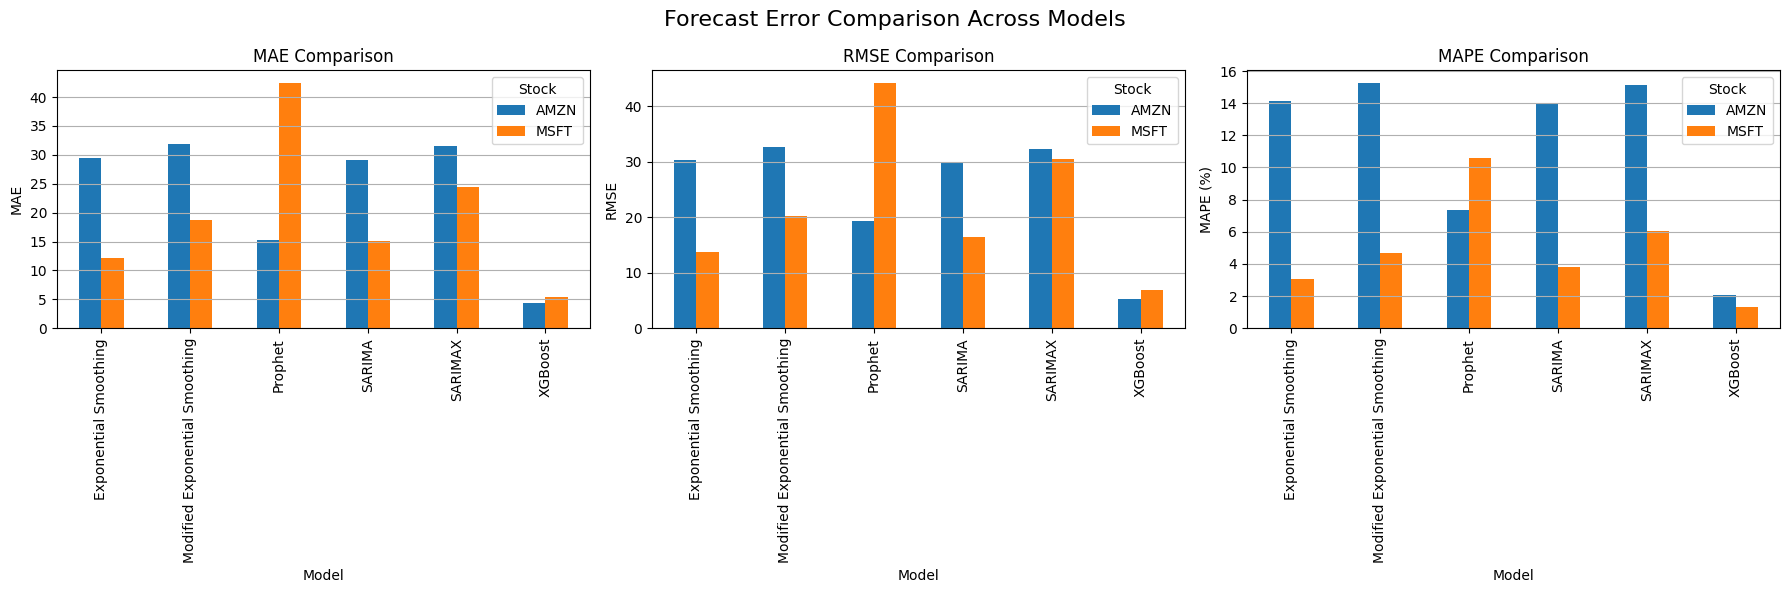

Best performing model by MAPE:
  AMZN: XGBoost (MAPE: 2.09%)
  MSFT: XGBoost (MAPE: 1.35%)


In [22]:
mae_plot = metrics_df.pivot(index="Model", columns="Stock", values="MAE")
rmse_plot = metrics_df.pivot(index="Model", columns="Stock", values="RMSE")
mape_plot = metrics_df.pivot(index="Model", columns="Stock", values="MAPE")

fig, axes = plt.subplots(1, 3, figsize=(18,6))
fig.suptitle("Forecast Error Comparison Across Models", fontsize=16)
mae_plot.plot(kind="bar", ax=axes[0])
axes[0].set_title("MAE Comparison")
axes[0].set_ylabel("MAE")
axes[0].set_xlabel("Model")
axes[0].grid(axis="y")

rmse_plot.plot(kind="bar", ax=axes[1])
axes[1].set_title("RMSE Comparison")
axes[1].set_ylabel("RMSE")
axes[1].set_xlabel("Model")
axes[1].grid(axis="y")

mape_plot.plot(kind="bar", ax=axes[2])
axes[2].set_title("MAPE Comparison")
axes[2].set_ylabel("MAPE (%)")
axes[2].set_xlabel("Model")
axes[2].grid(axis="y")

plt.tight_layout()
plt.show()

print("Best performing model by MAPE:")
for stock in ["AMZN", "MSFT"]:
    best = metrics_df[metrics_df["Stock"] == stock].sort_values("MAPE").iloc[0]
#forecast_comp_msft_future["Daily_Return"] = forecast_comp_msft_future["Close"].pct_change().dropna() * 100
    print(f"  {stock}: {best['Model']} (MAPE: {best['MAPE']}%)")

# Testinf for medias

In [23]:
#forecast_comp_msft_future["Daily_Return"] = forecast_comp_msft_future["Close"].pct_change().dropna() * 100


#print("------------------AMZN")
#print(forecast_comp_amzn_future)
#print("------------------MSFT")
#print(forecast_comp_msft_future)
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    pooled_std = np.sqrt(((nx - 1)*x.var() + (ny - 1)*y.var()) / (nx + ny - 2))
    return (x.mean() - y.mean()) / pooled_std
    
# 
# --- Step 1: Compute returns ---
amzn_returns = forecast_comp_amzn_future.pct_change().dropna() * 100
msft_returns = forecast_comp_msft_future.pct_change().dropna() * 100

# --- Step 2: Basic stats ---
print("AMZN mean return:", amzn_returns.mean())
print("MSFT mean return:", msft_returns.mean())

# --- Step 3: Verifying normality ---
stat_amzn, p_amzn = shapiro(amzn_returns)
stat_msft, p_msft = shapiro(msft_returns)
if p_amzn >0.05:
    print("AMZN Shapiro p-value:", p_amzn, " is approximately normal")
else:
    print("AMZN Shapiro p-value:", p_amzn, " is not approximately normal")

if p_msft >0.05:
    print("MSFT Shapiro p-value:", p_msft, " is approximately normal")
else:
    print("MSFT Shapiro p-value:", p_msft, " is not approximately normal")

# --- Step 4: Welch’s t-test ---
t_stat, p_value = stats.ttest_ind(amzn_returns, msft_returns, equal_var=False)

print("\nWelch's t-test:")
print("t-statistic:", t_stat)
print("p-value:", p_value)

# --- Step 5: Mann–Whitney U test---
u_stat, p_value_u = stats.mannwhitneyu(amzn_returns, msft_returns, alternative='two-sided')

print("\nMann-Whitney U test:")
print("U-statistic:", u_stat)
print("p-value:", p_value_u)

print("\nCohen's d:", cohens_d(amzn_returns, msft_returns))


AMZN mean return: 0.042949464
MSFT mean return: -7.871924e-05
AMZN Shapiro p-value: 0.9773970713906457  is approximately normal
MSFT Shapiro p-value: 0.6434376840895393  is approximately normal

Welch's t-test:
t-statistic: 0.47603787066551817
p-value: 0.6359320152105996

Mann-Whitney U test:
U-statistic: 445.5
p-value: 0.7031938694579425

Cohen's d: 0.12501366


In [24]:
# --- Effect size function ---
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    pooled_std = np.sqrt(((nx - 1)*x.var(ddof=1) + (ny - 1)*y.var(ddof=1)) / (nx + ny - 2))
    return (x.mean() - y.mean()) / pooled_std


# --- Step 1: Compute returns ---
amzn_returns = forecast_comp_amzn_future.pct_change().dropna() * 100
msft_returns = forecast_comp_msft_future.pct_change().dropna() * 100

print("Average daily return for each stock.\n")

# --- Step 2: Basic stats ---
print("AMZN mean return:", round(amzn_returns.mean(), 4), "%")
print("MSFT mean return:", round(msft_returns.mean(), 4), "%")

# --- Step 3: Verifying normality (Shapiro-Wilk test) ---
stat_amzn, p_amzn = shapiro(amzn_returns)
stat_msft, p_msft = shapiro(msft_returns)

print("Shapiro-Wilk Test (Normality Check):")

if p_amzn > 0.05:
    print("AMZN p-value:", round(p_amzn, 5), "-> Data is approximately normal")
else:
    print("AMZN p-value:", round(p_amzn, 5), "-> Data is NOT normal")

if p_msft > 0.05:
    print("MSFT p-value:", round(p_msft, 5), "-> Data is approximately normal")
else:
    print("MSFT p-value:", round(p_msft, 5), "-> Data is NOT normal")


Average daily return for each stock.

AMZN mean return: 0.0429 %
MSFT mean return: -1e-04 %
Shapiro-Wilk Test (Normality Check):
AMZN p-value: 0.9774 -> Data is approximately normal
MSFT p-value: 0.64344 -> Data is approximately normal


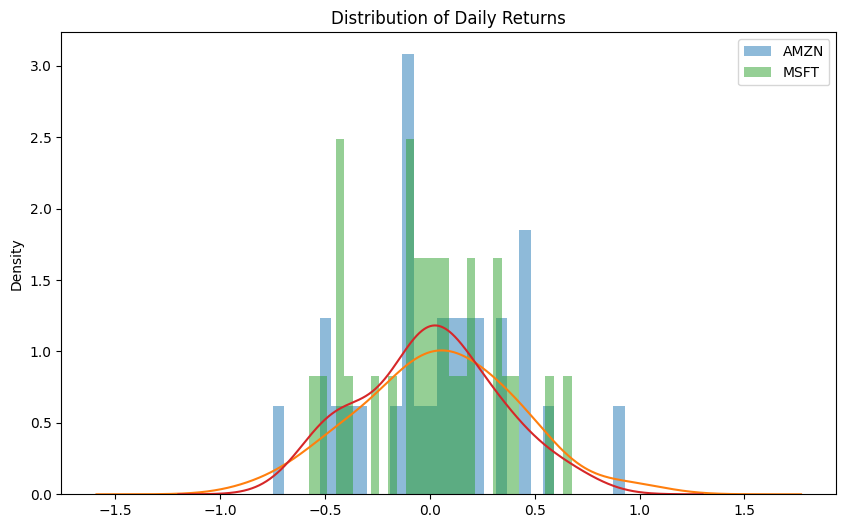

In [25]:
# Plot distributions
plt.figure(figsize=(10,6))

# AMZN
amzn_returns.plot(kind='hist', bins=30, density=True, alpha=0.5, label='AMZN')
amzn_returns.plot(kind='kde')

# MSFT
msft_returns.plot(kind='hist', bins=30, density=True, alpha=0.5, label='MSFT')
msft_returns.plot(kind='kde')

plt.title("Distribution of Daily Returns")
plt.legend()
plt.show()

In [26]:

# Choosing the right test
# --- Step 4: Welch’s t-test ---
if p_amzn > 0.05 and p_msft >0.05:
    t_stat, p_value = stats.ttest_ind(amzn_returns, msft_returns, equal_var=False)
    print("Welch's t-test (mean comparison, unequal variances). This is chosen since both series are normal:")
    print("t-statistic:", round(t_stat, 4))
    print("p-value:", round(p_value, 5))

    if p_value < 0.05:
        print("There is a Significant difference in mean returns")
    else:
        print("No statistically significant difference in mean returns")

# --- Step 5: Mann–Whitney U test ---
else:
    u_stat, p_value_u = stats.mannwhitneyu(amzn_returns, msft_returns, alternative='two-sided')
    print("Mann-Whitney U test (non-parametric), in case data is not normal:")
    print("U-statistic:", round(u_stat, 4))
    print("p-value:", round(p_value_u, 5))

    if p_value_u < 0.05:
        print("There is significant difference in distributions")
    else:
        print("No significant difference in distributions")


# --- Step 6: Effect size (Cohen’s d) ---
d = cohens_d(amzn_returns, msft_returns)

print("Cohen's d:", round(d, 4))

# Interpretation of effect size
abs_d = abs(d)

if abs_d < 0.2:
    print("-> Negligible effect size (almost no practical difference)")
elif abs_d < 0.5:
    print("-> Small effect size")
elif abs_d < 0.8:
    print("-> Medium effect size")
else:
    print("-> Large effect size")

Welch's t-test (mean comparison, unequal variances). This is chosen since both series are normal:
t-statistic: 0.476
p-value: 0.63593
No statistically significant difference in mean returns
Cohen's d: 0.125
-> Negligible effect size (almost no practical difference)


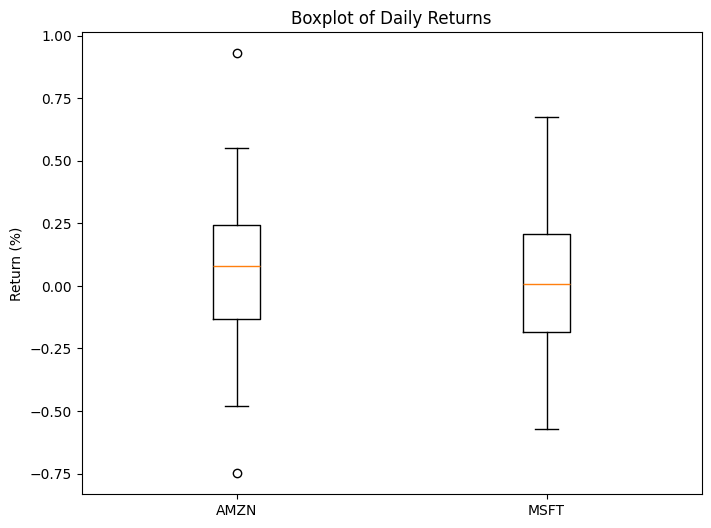

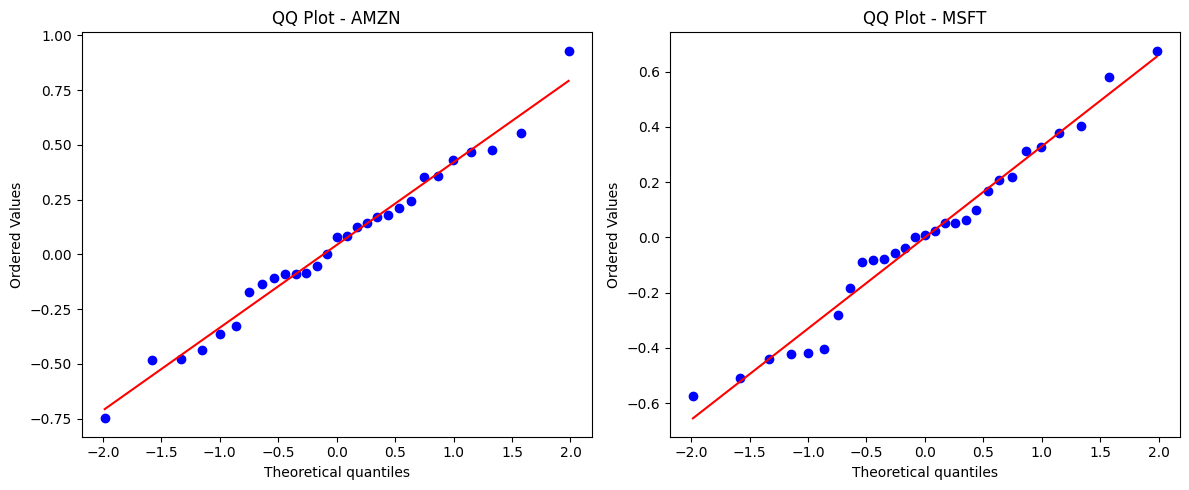

In [27]:
# Boxplots
plt.figure(figsize=(8,6))

plt.boxplot([amzn_returns, msft_returns], labels=["AMZN", "MSFT"])

plt.title("Boxplot of Daily Returns")
plt.ylabel("Return (%)")

plt.show()

# --- QQ Plots (normality visual check) ---
plt.figure(figsize=(12,5))

# AMZN QQ plot
plt.subplot(1,2,1)
stats.probplot(amzn_returns, dist="norm", plot=plt)
plt.title("QQ Plot - AMZN")

# MSFT QQ plot
plt.subplot(1,2,2)
stats.probplot(msft_returns, dist="norm", plot=plt)
plt.title("QQ Plot - MSFT")

plt.tight_layout()
plt.show()